# Air Pollution Forecasting — Phases 3, 4 & 5
## EDA · Pre-Processing · Model Order Selection
### Dataset: FinalData.csv | PM2.5 Daily (2001–2021)

**Columns:** Date, AQI, PM2.5, RH (Relative Humidity), Temperature, WindSpeed

**What this notebook covers:**

| Phase | Content |
|---|---|
| **Phase 3 — EDA** | Overview dashboard · Multi-variate analysis · ACF/PACF (raw) · Seasonal decomposition |
| **Phase 4 — Pre-Processing** | Log-transform · ADF stationarity tests · Transform comparison · Inverse-transform decisions |
| **Phase 5 — Model Order Selection** | ACF/PACF (stationary) · AIC grid search · Seasonal ACF · Periodogram · Final recommendations |

> **Note:** All statistical functions (ADF test, ACF, PACF, decomposition) are implemented from scratch using NumPy/SciPy — no statsmodels required.

---

## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from scipy import stats
from scipy.signal import periodogram
from sklearn.preprocessing import MinMaxScaler
import warnings, os, gc
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Output folder — change to '.' if running locally ──────────────
OUT = '.'
os.makedirs(OUT, exist_ok=True)

print("All imports OK")

All imports OK


## 1. Load & Inspect Dataset

> Reads `FinalData.csv`, parses dates, sorts chronologically, and caps
> wind speed outliers at the 99th percentile (values like 649 m/s are data errors —
> the 99th pct is ~10.5 m/s which is physically plausible).

In [2]:
# ── Update path if running locally ───────────────────────────────
DATA_PATH = '/content/sample_data/FinalData.csv'

df_raw = pd.read_csv(DATA_PATH)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

# Clean WindSpeed outliers (>99th percentile and < 0)
wind_cap = np.percentile(df_raw['WindSpeed'], 99)
df_raw['WindSpeed'] = df_raw['WindSpeed'].clip(lower=0, upper=wind_cap)

TARGET = 'PM2.5'
EXOG   = ['AQI', 'RH', 'Temperature', 'WindSpeed']

print(f"Date range : {df_raw['Date'].min().date()} → {df_raw['Date'].max().date()}")
print(f"Shape      : {df_raw.shape}")
print(f"Columns    : {list(df_raw.columns)}")
print(f"\nMissing values:\n{df_raw.isnull().sum().to_string()}")
print(f"\nWindSpeed capped at {wind_cap:.2f} m/s (99th percentile)")
print(f"\nDescriptive statistics:")
df_raw[TARGET].describe().round(3)

Date range : 2001-01-01 → 2021-12-31
Shape      : (7670, 6)
Columns    : ['Date', 'AQI', 'PM2.5', 'RH', 'Temperature', 'WindSpeed']

Missing values:
Date           0
AQI            0
PM2.5          0
RH             0
Temperature    0
WindSpeed      0

WindSpeed capped at 10.47 m/s (99th percentile)

Descriptive statistics:


,PM2.5
count,7670.000
mean,10.214
std,6.622
min,0.009
25%,5.701
50%,8.370
75%,12.752
max,80.960


In [3]:
# Full descriptive stats for all columns
print("=== DESCRIPTIVE STATISTICS ===")
desc = df_raw[[TARGET]+EXOG].describe().round(3)
print(desc.to_string())

print(f"\nSkewness:")
for col in [TARGET]+EXOG:
    print(f"  {col:<15}: {df_raw[col].skew():.4f}")

print(f"\nCorrelations with PM2.5:")
for col in EXOG:
    print(f"  {col:<15}: {df_raw[TARGET].corr(df_raw[col]):.4f}")

=== DESCRIPTIVE STATISTICS ===
          PM2.5       AQI        RH  Temperature  WindSpeed
count  7670.000  7670.000  7670.000     7670.000   7670.000
mean     10.214    45.712    66.842       13.631      3.977
std       6.622    18.688    14.549        7.834      1.921
min       0.009     2.864    19.433       -5.936      0.000
25%       5.701    31.416    56.522        6.649      2.599
50%       8.370    44.533    66.982       13.646      3.596
75%      12.752    57.333    77.582       21.130      4.952
max      80.960   168.814    99.500       27.215     10.469

Skewness:
  PM2.5          : 1.9813
  AQI            : 0.7075
  RH             : -0.0991
  Temperature    : -0.1011
  WindSpeed      : 1.0265

Correlations with PM2.5:
  AQI            : 0.9631
  RH             : 0.2358
  Temperature    : 0.0510
  WindSpeed      : -0.1444


## 2. Helper Functions
> ADF test, ACF, PACF, and decomposition — all implemented from scratch using NumPy/SciPy.
> No external time-series library required.

In [4]:
# ══════════════════════════════════════════════════════════════════
# ADF TEST  (Augmented Dickey-Fuller)
# H0: unit root (non-stationary)  |  Ha: stationary
# Implemented via OLS regression + MacKinnon (1994) critical values
# ══════════════════════════════════════════════════════════════════
def adf_test(series, maxlag=None, regression='c'):
    """
    Augmented Dickey-Fuller test implemented from scratch via OLS.

    Parameters
    ----------
    series     : array-like
    maxlag     : int or None (auto: Schwert criterion)
    regression : 'c'  = constant (default)
                 'ct' = constant + trend
                 'nc' = no constant

    Returns
    -------
    dict with keys: stat, pval, lags, cv1, cv5, cv10, stationary
    """
    series = np.asarray(series, dtype=float)
    series = series[~np.isnan(series)]
    n = len(series)

    if maxlag is None:
        maxlag = min(int(np.ceil(12.0 * (n / 100.) ** 0.25)), 15)

    dy      = np.diff(series)
    nobs    = len(dy) - maxlag
    y       = dy[maxlag:]
    xlev    = series[maxlag:-1]
    lag_cols = [dy[maxlag - k: len(dy) - k] for k in range(1, maxlag + 1)]

    if regression == 'nc':
        X = np.column_stack([xlev] + lag_cols) if lag_cols else xlev.reshape(-1, 1)
    elif regression == 'c':
        X = np.column_stack([xlev] + lag_cols + [np.ones(nobs)])
    elif regression == 'ct':
        X = np.column_stack([xlev] + lag_cols + [np.ones(nobs), np.arange(1, nobs + 1)])

    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    df_e  = nobs - X.shape[1]
    s2    = resid @ resid / df_e
    cov   = s2 * np.linalg.pinv(X.T @ X)
    t_stat = beta[0] / np.sqrt(cov[0, 0])

    # MacKinnon (1994) critical values
    cv_map = {
        'c':  {0.01: -3.4336, 0.05: -2.8629, 0.10: -2.5674},
        'ct': {0.01: -3.9596, 0.05: -3.4105, 0.10: -3.1274},
        'nc': {0.01: -2.5658, 0.05: -1.9393, 0.10: -1.6156},
    }
    cv = cv_map[regression]

    # Approximate p-value via linear interpolation
    ref_t = np.array([-3.4336, -2.8629, -2.5674, -2.225, -1.9393, -1.6156, 0.0])
    ref_p = np.array([0.01,     0.05,    0.10,    0.20,   0.30,    0.50,    0.90])
    pval  = float(np.clip(np.interp(t_stat, ref_t, ref_p), 0.001, 0.999))

    return {
        'stat':       round(t_stat, 4),
        'pval':       round(pval,   4),
        'lags':       maxlag,
        'cv1':        cv[0.01],
        'cv5':        cv[0.05],
        'cv10':       cv[0.10],
        'stationary': t_stat < cv[0.05],
    }


# ══════════════════════════════════════════════════════════════════
# ACF — Autocorrelation Function
# ══════════════════════════════════════════════════════════════════
def acf(x, nlags=40):
    """Sample ACF at lags 0..nlags."""
    x  = np.asarray(x, dtype=float)
    x  = x[~np.isnan(x)]
    xd = x - x.mean()
    n  = len(x)
    var = np.dot(xd, xd) / n
    return np.array([1.0] + [np.dot(xd[k:], xd[:n - k]) / (n * var)
                              for k in range(1, nlags + 1)])


# ══════════════════════════════════════════════════════════════════
# PACF — Partial Autocorrelation Function (OLS method)
# ══════════════════════════════════════════════════════════════════
def pacf_ols(x, nlags=40):
    """PACF via successive OLS regressions."""
    x   = np.asarray(x, dtype=float)
    x   = x[~np.isnan(x)]
    n   = len(x)
    pac = [1.0]
    for lag in range(1, nlags + 1):
        y_  = x[lag:]
        X_  = np.column_stack([x[lag - k - 1: n - k - 1] for k in range(lag)])
        b, _, _, _ = np.linalg.lstsq(X_, y_, rcond=None)
        pac.append(b[-1])
    return np.array(pac)


# ══════════════════════════════════════════════════════════════════
# 95% Confidence Band for ACF/PACF
# ══════════════════════════════════════════════════════════════════
def conf_band(n, nlags, alpha=0.05):
    return stats.norm.ppf(1 - alpha / 2) / np.sqrt(n) * np.ones(nlags + 1)


# ══════════════════════════════════════════════════════════════════
# ADDITIVE DECOMPOSITION (trend via centred MA, seasonal by averaging)
# ══════════════════════════════════════════════════════════════════
def manual_decompose(series, period=365):
    """
    Additive decomposition: Observed = Trend + Seasonal + Residual.
    Trend via centred moving average of 'period' length.
    """
    s    = np.asarray(series, dtype=float)
    n    = len(s)
    half = period // 2

    # Trend
    trend = np.full(n, np.nan)
    for i in range(half, n - half):
        trend[i] = np.mean(s[i - half: i + half + 1])

    # De-trended
    detrended = s - trend

    # Seasonal: average over positions within each period
    seasonal = np.zeros(n)
    for pos in range(period):
        idx = np.arange(pos, n, period)
        seasonal[idx] = np.nanmean(detrended[idx])

    residual = s - trend - seasonal
    return trend, seasonal, residual


print("Helper functions defined: adf_test, acf, pacf_ols, conf_band, manual_decompose")

Helper functions defined: adf_test, acf, pacf_ols, conf_band, manual_decompose


## Phase 3 — Exploratory Data Analysis

### 3.1 Overview Dashboard

> Six-panel overview of the full dataset:
> - **Top row:** Full PM2.5 time series with annual mean overlay and WHO thresholds
> - **Middle row:** Distribution (right-skewed), monthly seasonality boxplot, annual trend bar chart
> - **Bottom row:** 30-day and 365-day rolling MA, feature correlations, Wind vs PM2.5 scatter
>
> **Key interpretation:** The slow-declining annual trend, strong seasonal pattern (winter peaks),
> and right-skewed distribution all have direct implications for model choice.

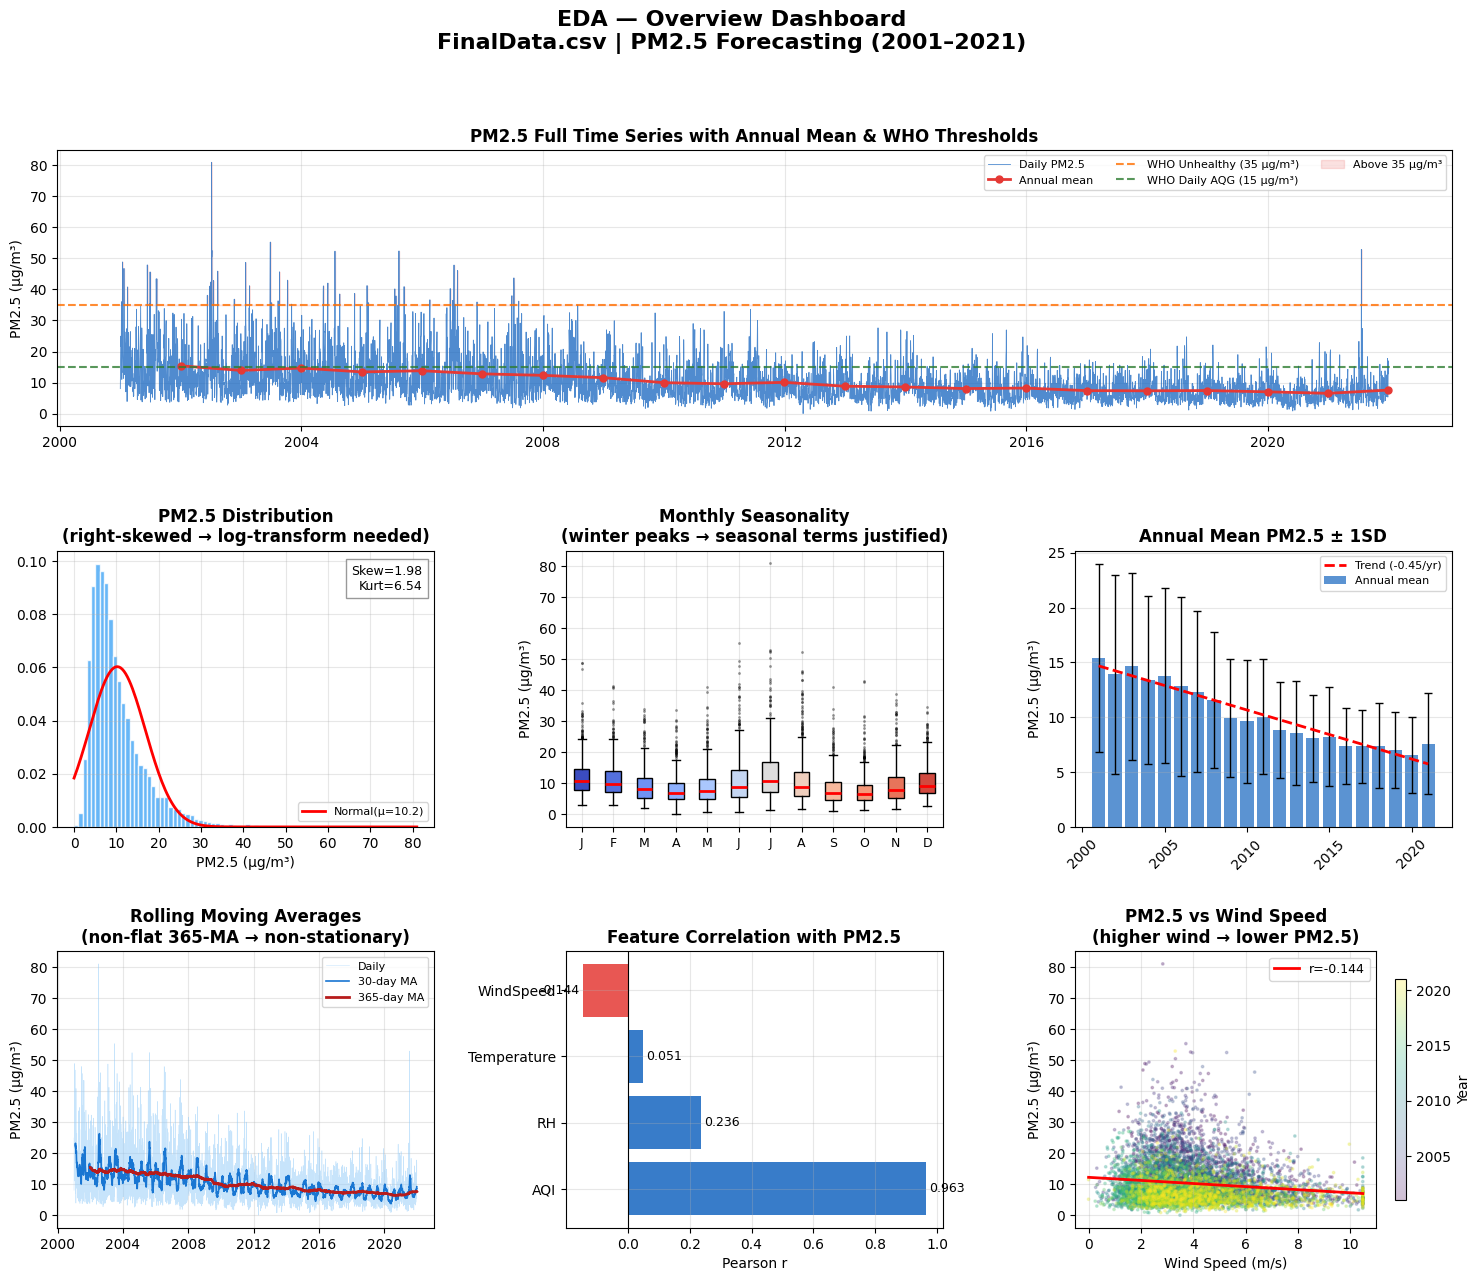


Key stats:
  PM2.5  mean=10.21  std=6.62  skew=1.981  kurt=6.541
  Annual trend: -0.447 µg/m³/yr


In [5]:
pm_vals = df_raw[TARGET].values

fig = plt.figure(figsize=(18, 14))
fig.suptitle('EDA — Overview Dashboard\nFinalData.csv | PM2.5 Forecasting (2001–2021)',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Full time series ────────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(df_raw['Date'], df_raw[TARGET], lw=0.6, color='#1565C0', alpha=0.75, label='Daily PM2.5')
annual_mean = df_raw.set_index('Date')[TARGET].resample('YE').mean()
ax.plot(annual_mean.index, annual_mean.values, 'o-', color='#E53935', lw=2, ms=5, label='Annual mean')
ax.axhline(35, color='#FF6F00', lw=1.5, ls='--', alpha=0.8, label='WHO Unhealthy (35 µg/m³)')
ax.axhline(15, color='#2E7D32', lw=1.5, ls='--', alpha=0.8, label='WHO Daily AQG (15 µg/m³)')
ax.fill_between(df_raw['Date'], 35, df_raw[TARGET].clip(lower=35),
                alpha=0.15, color='#E53935', label='Above 35 µg/m³')
ax.set_title('PM2.5 Full Time Series with Annual Mean & WHO Thresholds', fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8, ncol=3); ax.grid(alpha=0.3)

# ── Distribution ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.hist(df_raw[TARGET], bins=80, color='#42A5F5', edgecolor='white', lw=0.3,
        density=True, alpha=0.8)
xfit = np.linspace(df_raw[TARGET].min(), df_raw[TARGET].max(), 200)
mu, sigma = df_raw[TARGET].mean(), df_raw[TARGET].std()
ax.plot(xfit, stats.norm.pdf(xfit, mu, sigma), 'r-', lw=2, label=f'Normal(μ={mu:.1f})')
skew = df_raw[TARGET].skew()
kurt = df_raw[TARGET].kurtosis()
ax.text(0.97, 0.95, f'Skew={skew:.2f}\nKurt={kurt:.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(fc='white', ec='gray', alpha=0.8))
ax.set_title('PM2.5 Distribution\n(right-skewed → log-transform needed)', fontweight='bold')
ax.set_xlabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Monthly boxplot ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
df_raw['month'] = df_raw['Date'].dt.month
monthly = [df_raw[df_raw['month'] == m][TARGET].values for m in range(1, 13)]
bp = ax.boxplot(monthly, patch_artist=True, medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='.', ms=2, alpha=0.4))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(plt.cm.coolwarm(i / 12))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=9)
ax.set_title('Monthly Seasonality\n(winter peaks → seasonal terms justified)', fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)'); ax.grid(alpha=0.3)

# ── Annual mean trend ────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
yr_mean = df_raw.groupby(df_raw['Date'].dt.year)[TARGET].mean()
yr_std  = df_raw.groupby(df_raw['Date'].dt.year)[TARGET].std()
ax.bar(yr_mean.index, yr_mean.values, color='#1565C0', alpha=0.7, label='Annual mean')
ax.errorbar(yr_mean.index, yr_mean.values, yerr=yr_std.values,
            fmt='none', color='black', capsize=3, lw=1)
z = np.polyfit(yr_mean.index, yr_mean.values, 1)
ax.plot(yr_mean.index, np.polyval(z, yr_mean.index), 'r--', lw=2,
        label=f'Trend ({z[0]:+.2f}/yr)')
ax.set_title('Annual Mean PM2.5 ± 1SD', fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

# ── Rolling moving averages ──────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
pm_s = df_raw[TARGET]
ax.plot(df_raw['Date'], pm_s, lw=0.4, color='#90CAF9', alpha=0.5, label='Daily')
ax.plot(df_raw['Date'], pm_s.rolling(30).mean(),  lw=1.2, color='#1976D2', label='30-day MA')
ax.plot(df_raw['Date'], pm_s.rolling(365).mean(), lw=2.0, color='#B71C1C', label='365-day MA')
ax.set_title('Rolling Moving Averages\n(non-flat 365-MA → non-stationary)', fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Feature correlations ─────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
corrs = {col: df_raw[TARGET].corr(df_raw[col]) for col in EXOG}
colors_c = ['#1565C0' if v >= 0 else '#E53935' for v in corrs.values()]
bars_ = ax.barh(list(corrs.keys()), list(corrs.values()), color=colors_c, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
for bar_, val in zip(bars_, corrs.values()):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar_.get_y() + bar_.get_height() / 2,
            f'{val:.3f}', ha='left' if val >= 0 else 'right', va='center', fontsize=9)
ax.set_title('Feature Correlation with PM2.5', fontweight='bold')
ax.set_xlabel('Pearson r'); ax.grid(alpha=0.3)

# ── Wind vs PM2.5 scatter ────────────────────────────────────────
ax = fig.add_subplot(gs[2, 2])
sc = ax.scatter(df_raw['WindSpeed'], df_raw[TARGET], s=3, alpha=0.25,
                c=df_raw['Date'].dt.year, cmap='viridis')
z2 = np.polyfit(df_raw['WindSpeed'], df_raw[TARGET], 1)
xf = np.linspace(df_raw['WindSpeed'].min(), df_raw['WindSpeed'].max(), 100)
ax.plot(xf, np.polyval(z2, xf), 'r-', lw=2, label=f'r={corrs["WindSpeed"]:.3f}')
plt.colorbar(sc, ax=ax, label='Year', shrink=0.8)
ax.set_title('PM2.5 vs Wind Speed\n(higher wind → lower PM2.5)', fontweight='bold')
ax.set_xlabel('Wind Speed (m/s)'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.savefig(f'{OUT}/P3_01_overview.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

print(f"\nKey stats:")
print(f"  PM2.5  mean={df_raw[TARGET].mean():.2f}  std={df_raw[TARGET].std():.2f}  "
      f"skew={skew:.3f}  kurt={kurt:.3f}")
print(f"  Annual trend: {np.polyfit(yr_mean.index, yr_mean.values, 1)[0]:+.3f} µg/m³/yr")

### 3.2 Multi-Variate Analysis

> Scatter plots of each feature against PM2.5, day-of-week pattern, PM2.5 vs Temperature
> dual-axis overlay, and Q-Q normality plot.
>
> **Key insight from Q-Q plot:** heavy right tail confirms departure from normality → log-transform required.

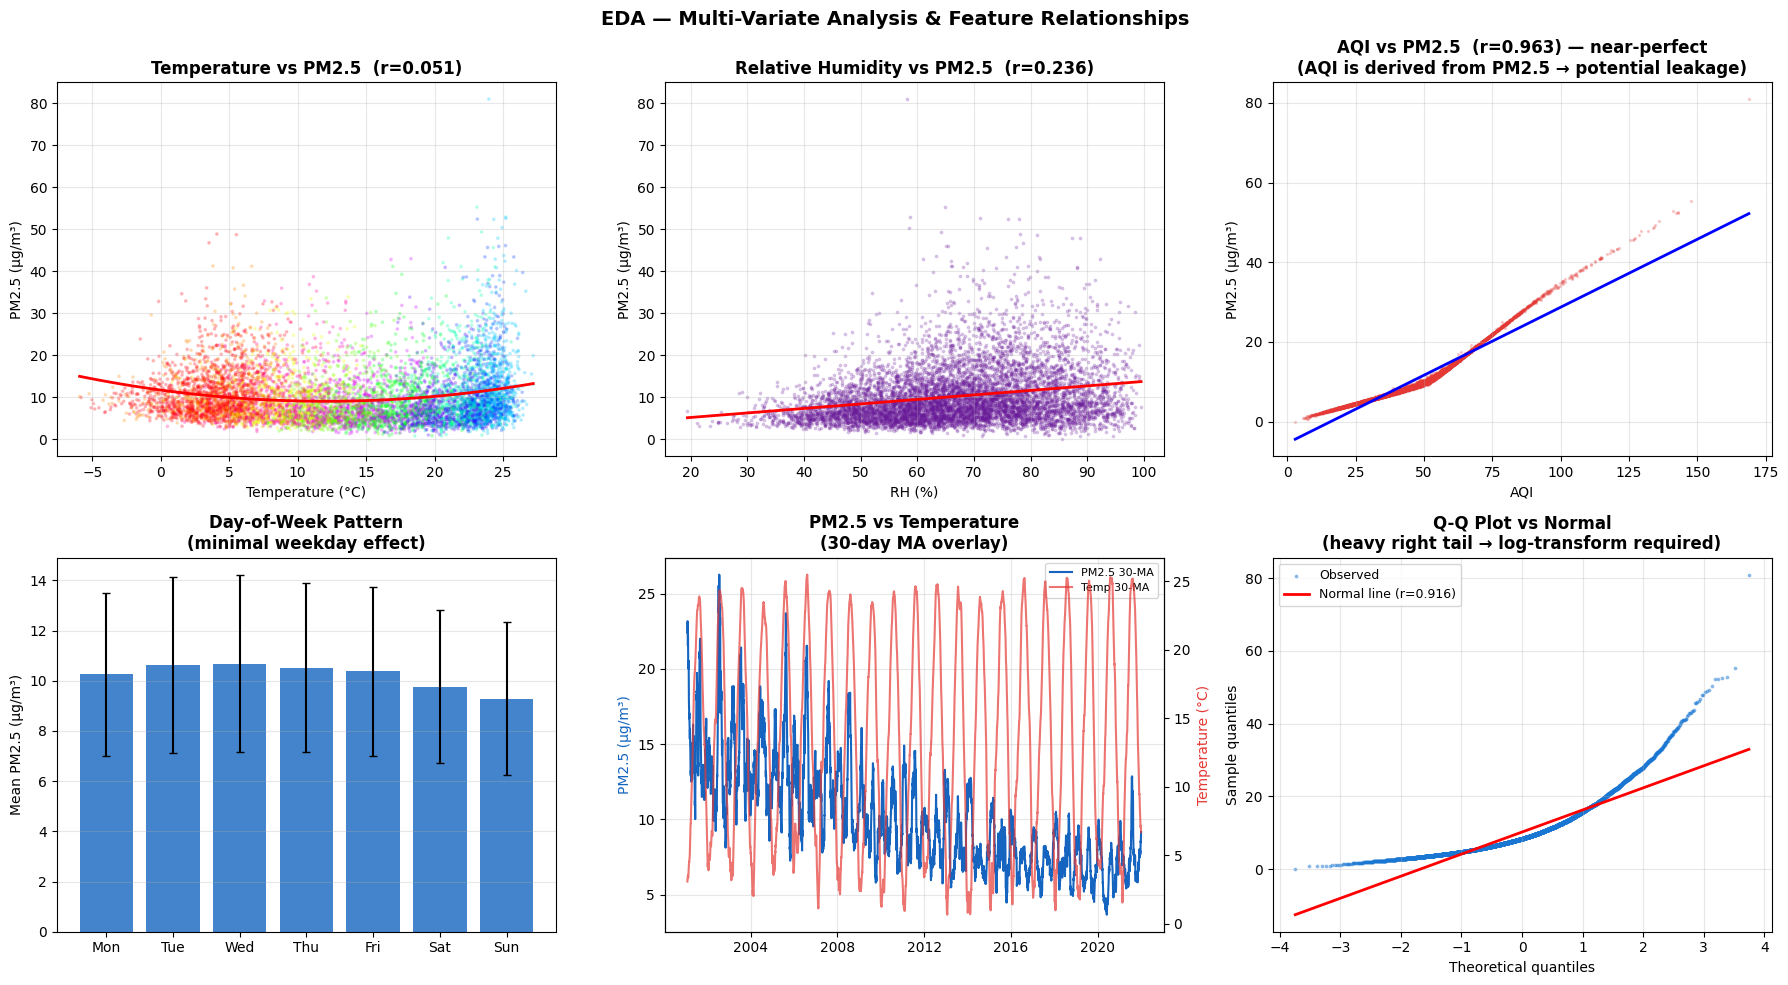

0

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Multi-Variate Analysis & Feature Relationships',
             fontsize=14, fontweight='bold')

# Temperature vs PM2.5
ax = axes[0, 0]
ax.scatter(df_raw['Temperature'], df_raw[TARGET], s=3, alpha=0.2,
           c=df_raw['month'], cmap='hsv')
z3  = np.polyfit(df_raw['Temperature'], df_raw[TARGET], 2)
xf3 = np.linspace(df_raw['Temperature'].min(), df_raw['Temperature'].max(), 100)
ax.plot(xf3, np.polyval(z3, xf3), 'r-', lw=2)
r_temp = df_raw[TARGET].corr(df_raw['Temperature'])
ax.set_title(f'Temperature vs PM2.5  (r={r_temp:.3f})', fontweight='bold')
ax.set_xlabel('Temperature (°C)'); ax.set_ylabel('PM2.5 (µg/m³)'); ax.grid(alpha=0.3)

# RH vs PM2.5
ax = axes[0, 1]
ax.scatter(df_raw['RH'], df_raw[TARGET], s=3, alpha=0.2, color='#6A1B9A')
z4  = np.polyfit(df_raw['RH'], df_raw[TARGET], 1)
xf4 = np.linspace(df_raw['RH'].min(), df_raw['RH'].max(), 100)
ax.plot(xf4, np.polyval(z4, xf4), 'r-', lw=2)
r_rh = df_raw[TARGET].corr(df_raw['RH'])
ax.set_title(f'Relative Humidity vs PM2.5  (r={r_rh:.3f})', fontweight='bold')
ax.set_xlabel('RH (%)'); ax.set_ylabel('PM2.5 (µg/m³)'); ax.grid(alpha=0.3)

# AQI vs PM2.5
ax = axes[0, 2]
ax.scatter(df_raw['AQI'], df_raw[TARGET], s=2, alpha=0.2, color='#E53935')
z5  = np.polyfit(df_raw['AQI'], df_raw[TARGET], 1)
xf5 = np.linspace(df_raw['AQI'].min(), df_raw['AQI'].max(), 100)
ax.plot(xf5, np.polyval(z5, xf5), 'b-', lw=2)
r_aqi = df_raw[TARGET].corr(df_raw['AQI'])
ax.set_title(f'AQI vs PM2.5  (r={r_aqi:.3f}) — near-perfect\n'
             f'(AQI is derived from PM2.5 → potential leakage)', fontweight='bold')
ax.set_xlabel('AQI'); ax.set_ylabel('PM2.5 (µg/m³)'); ax.grid(alpha=0.3)

# Day-of-week pattern
ax = axes[1, 0]
df_raw['dow'] = df_raw['Date'].dt.dayofweek
dow_mean = df_raw.groupby('dow')[TARGET].mean()
dow_std  = df_raw.groupby('dow')[TARGET].std()
ax.bar(range(7), dow_mean.values, color='#1565C0', alpha=0.8,
       yerr=dow_std.values / 2, capsize=3)
ax.set_xticks(range(7))
ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_title('Day-of-Week Pattern\n(minimal weekday effect)', fontweight='bold')
ax.set_ylabel('Mean PM2.5 (µg/m³)'); ax.grid(alpha=0.3, axis='y')

# PM2.5 vs Temperature dual-axis overlay
ax  = axes[1, 1]
ax2 = ax.twinx()
ax.plot(df_raw['Date'], df_raw[TARGET].rolling(30).mean(),
        lw=1.5, color='#1565C0', label='PM2.5 30-MA')
ax2.plot(df_raw['Date'], df_raw['Temperature'].rolling(30).mean(),
         lw=1.5, color='#E53935', alpha=0.7, label='Temp 30-MA')
ax.set_ylabel('PM2.5 (µg/m³)', color='#1565C0')
ax2.set_ylabel('Temperature (°C)', color='#E53935')
ax.set_title('PM2.5 vs Temperature\n(30-day MA overlay)', fontweight='bold')
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lb1 + lb2, fontsize=8, loc='upper right')
ax.grid(alpha=0.3)

# Q-Q plot
ax = axes[1, 2]
(osm, osr), (slope, intercept, r_qq) = stats.probplot(df_raw[TARGET], dist='norm')
ax.scatter(osm, osr, s=3, alpha=0.4, color='#1976D2', label='Observed')
xq = np.array([osm[0], osm[-1]])
ax.plot(xq, slope * xq + intercept, 'r-', lw=2,
        label=f'Normal line (r={r_qq:.3f})')
ax.set_title('Q-Q Plot vs Normal\n(heavy right tail → log-transform required)',
             fontweight='bold')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/P3_02_multivariate.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

### 3.3 ACF & PACF — Raw Series

> The Autocorrelation Function (ACF) measures total correlation at each lag.
> The Partial Autocorrelation Function (PACF) measures direct correlation after removing
> the effect of intermediate lags.
>
> **Reading guide:**
> - ACF decays **slowly/geometrically** → AR structure present, series may be non-stationary
> - ACF **cuts off** sharply at lag q → MA(q) process → q value for ARIMA
> - PACF **cuts off** sharply at lag p → AR(p) process → p value for ARIMA
> - Red dashed lines = 95% confidence bands (±1.96/√n)

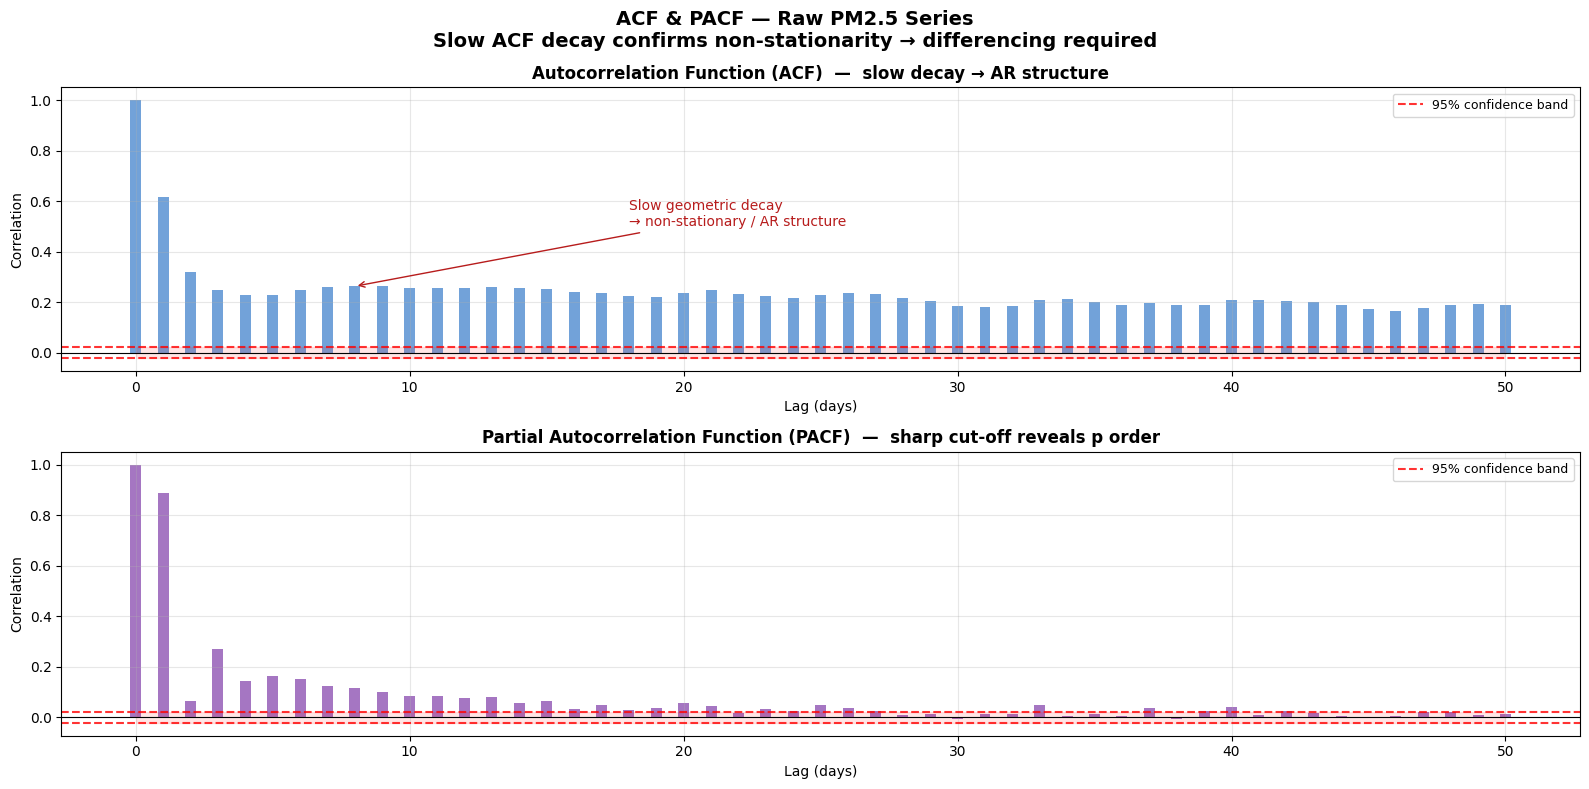

Observations:
  ACF  at lag-1:  0.6150  (high → strong AR signal)
  PACF at lag-1:  0.8861
  PACF at lag-2:  0.0655
  ACF  at lag-7:  0.2590  (weekly pattern?)


In [7]:
NLAGS = 50
acf_vals  = acf(pm_vals, NLAGS)
pacf_vals = pacf_ols(pm_vals, NLAGS)
cb        = conf_band(len(pm_vals), NLAGS)
lags      = np.arange(NLAGS + 1)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('ACF & PACF — Raw PM2.5 Series\n'
             'Slow ACF decay confirms non-stationarity → differencing required',
             fontsize=14, fontweight='bold')

for ax, vals, title, color in zip(
        axes,
        [acf_vals, pacf_vals],
        ['Autocorrelation Function (ACF)  —  slow decay → AR structure',
         'Partial Autocorrelation Function (PACF)  —  sharp cut-off reveals p order'],
        ['#1565C0', '#6A1B9A']):
    ax.bar(lags, vals, color=color, alpha=0.6, width=0.4)
    ax.axhline(0,      color='black', lw=0.8)
    ax.axhline( cb[0], color='red', lw=1.5, ls='--', alpha=0.8, label='95% confidence band')
    ax.axhline(-cb[0], color='red', lw=1.5, ls='--', alpha=0.8)
    ax.fill_between(lags, -cb, cb, alpha=0.1, color='red')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Lag (days)'); ax.set_ylabel('Correlation')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes[0].annotate('Slow geometric decay\n→ non-stationary / AR structure',
                 xy=(8, acf_vals[8]), xytext=(18, 0.5), fontsize=10, color='#B71C1C',
                 arrowprops=dict(arrowstyle='->', color='#B71C1C'))

plt.tight_layout()
plt.savefig(f'{OUT}/P3_03_acf_pacf_raw.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

print("Observations:")
print(f"  ACF  at lag-1:  {acf_vals[1]:.4f}  (high → strong AR signal)")
print(f"  PACF at lag-1:  {pacf_vals[1]:.4f}")
print(f"  PACF at lag-2:  {pacf_vals[2]:.4f}")
print(f"  ACF  at lag-7:  {acf_vals[7]:.4f}  (weekly pattern?)")

### 3.4 Seasonal Decomposition (Additive, Period = 365 days)

> Additive model: **Observed = Trend + Seasonal + Residual**
>
> - **Trend:** extracted via 365-day centred moving average → shows long-run decline
> - **Seasonal:** average value at each calendar position → shows winter peak pattern
> - **Residual:** what remains after removing both → should be approximately white noise
>
> **Decision from this plot:** Declining trend → d ≥ 1 needed. Strong seasonal component → SARIMA warranted.

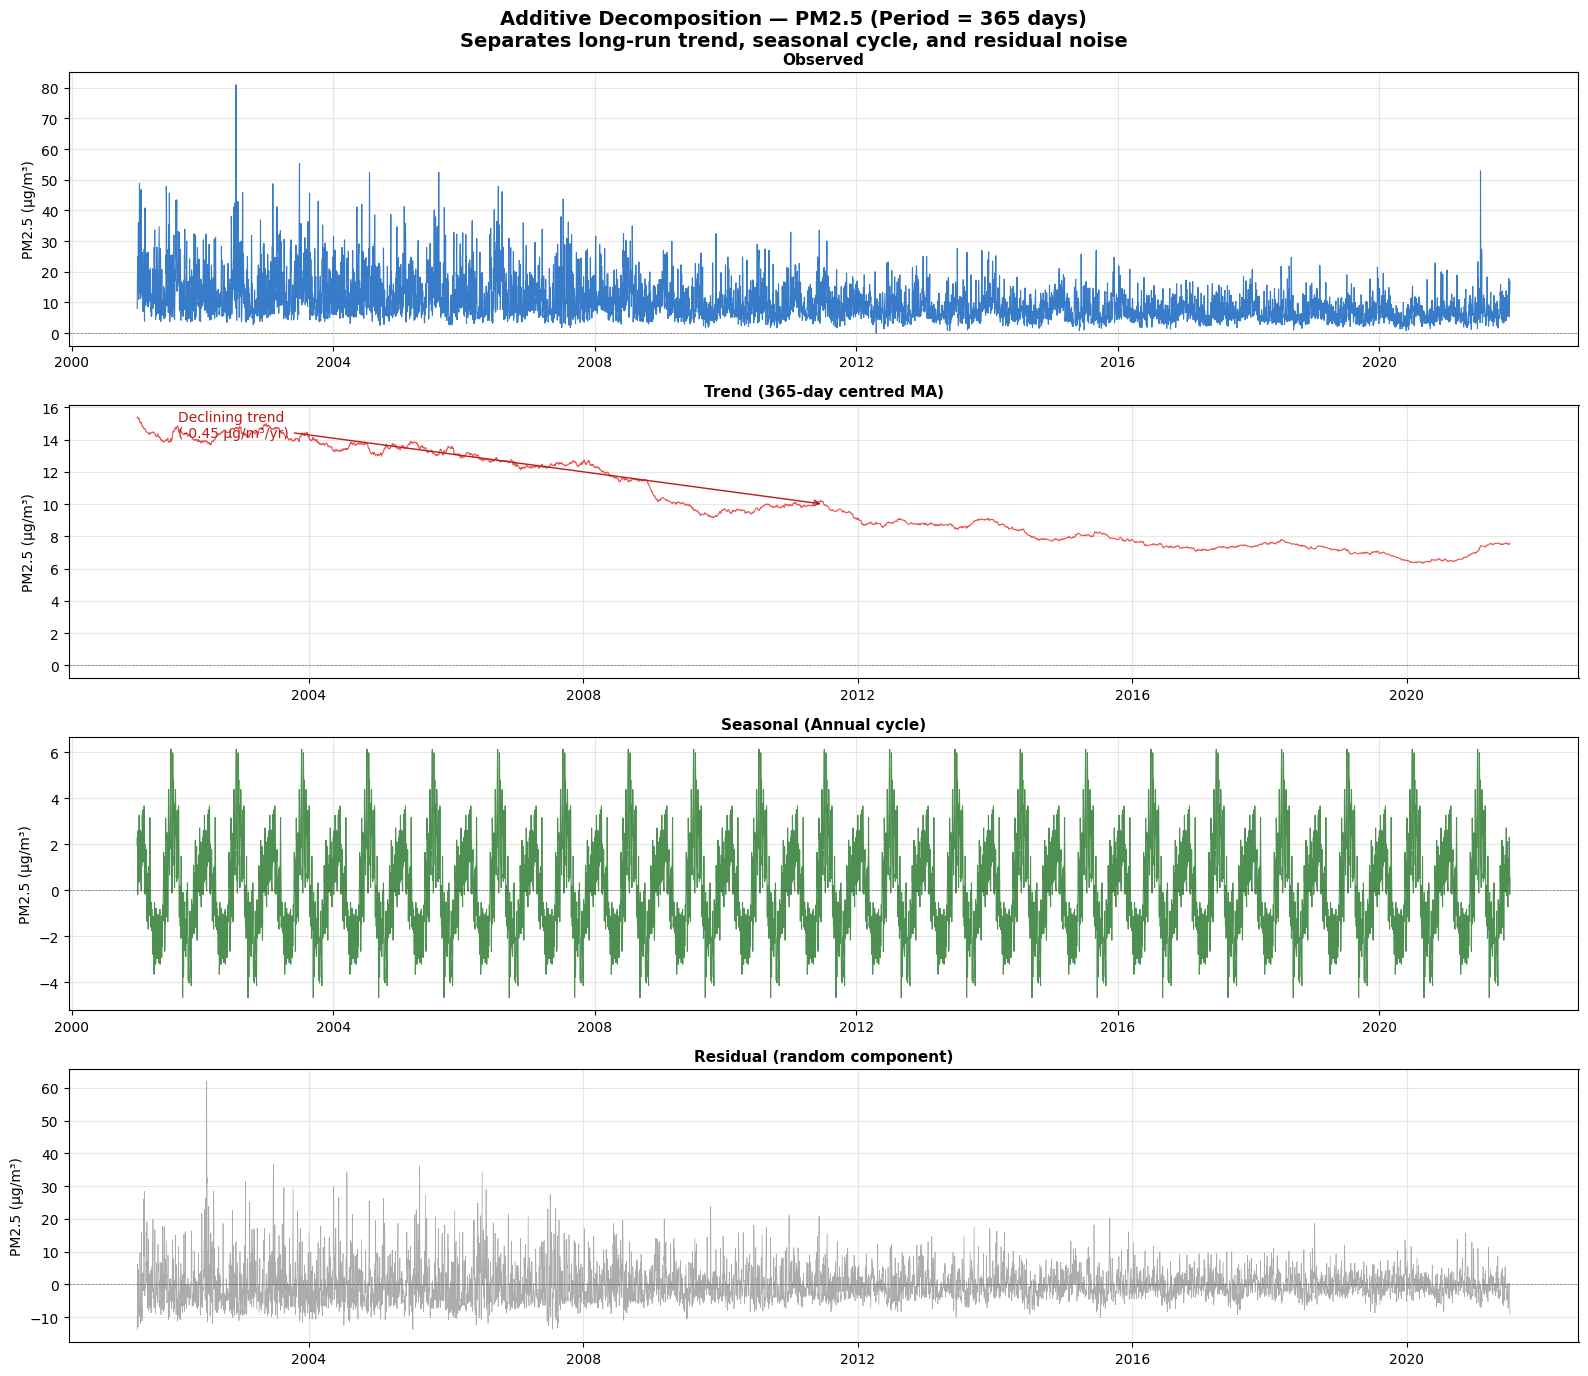

Decomposition summary:
  Trend slope     : -0.454 µg/m³/yr
  Seasonal range  : 10.79 µg/m³
  Residual std    : 5.55 µg/m³


In [8]:
trend_365, seasonal_365, resid_365 = manual_decompose(pm_vals, period=365)
dates = df_raw['Date'].values

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Additive Decomposition — PM2.5 (Period = 365 days)\n'
             'Separates long-run trend, seasonal cycle, and residual noise',
             fontsize=14, fontweight='bold')

panels = [
    (pm_vals,      'Observed',                      '#1565C0'),
    (trend_365,    'Trend (365-day centred MA)',     '#E53935'),
    (seasonal_365, 'Seasonal (Annual cycle)',        '#2E7D32'),
    (resid_365,    'Residual (random component)',    '#9E9E9E'),
]
for ax, (vals, lbl, col) in zip(axes, panels):
    ax.plot(dates, vals, lw=0.8 if lbl != 'Residual (random component)' else 0.5,
            color=col, alpha=0.85)
    ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.5)
    ax.set_title(lbl, fontweight='bold', fontsize=11)
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.grid(alpha=0.3)

# Annotate trend direction
trend_clean = trend_365[~np.isnan(trend_365)]
trend_dates = dates[~np.isnan(trend_365)]
slope_trend = np.polyfit(np.arange(len(trend_clean)), trend_clean, 1)[0] * 365
axes[1].annotate(f'Declining trend\n({slope_trend:.2f} µg/m³/yr)',
                 xy=(trend_dates[len(trend_dates) // 2],
                     trend_clean[len(trend_clean) // 2]),
                 xytext=(dates[400], trend_clean.max() * 0.92),
                 fontsize=10, color='#B71C1C',
                 arrowprops=dict(arrowstyle='->', color='#B71C1C'))

plt.tight_layout()
plt.savefig(f'{OUT}/P3_04_decomposition.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

print("Decomposition summary:")
print(f"  Trend slope     : {slope_trend:.3f} µg/m³/yr")
print(f"  Seasonal range  : {np.nanmax(seasonal_365) - np.nanmin(seasonal_365):.2f} µg/m³")
print(f"  Residual std    : {np.nanstd(resid_365):.2f} µg/m³")

## Phase 4 — Pre-Processing

### 4.1 Is Log-Transform Required?

> **Decision rule:** Apply `log(1 + PM2.5)` if:
> - Skewness > 1 (distribution is right-skewed), **OR**
> - Variance is heteroskedastic (varies over time — check with yearly CV of std)
>
> **Why log1p instead of log?** PM2.5 can theoretically be zero; `log1p(x) = log(1+x)`
> is defined at x=0 and is the standard transform for non-negative count/concentration data.

=== LOG-TRANSFORM JUSTIFICATION ===
  Skewness (raw)    : 1.9813  → >1 means right-skewed
  Skewness (log)    : 0.2590  → much closer to 0
  CV of yearly σ (raw)  : 0.3480  → variance changes year to year
  CV of yearly σ (log)  : 0.0202  → much more stable after log

Decision: LOG-TRANSFORM IS REQUIRED
  → Apply np.log1p(PM2.5) before fitting ARIMA models
  → Inverse: np.expm1(forecast) to recover original scale


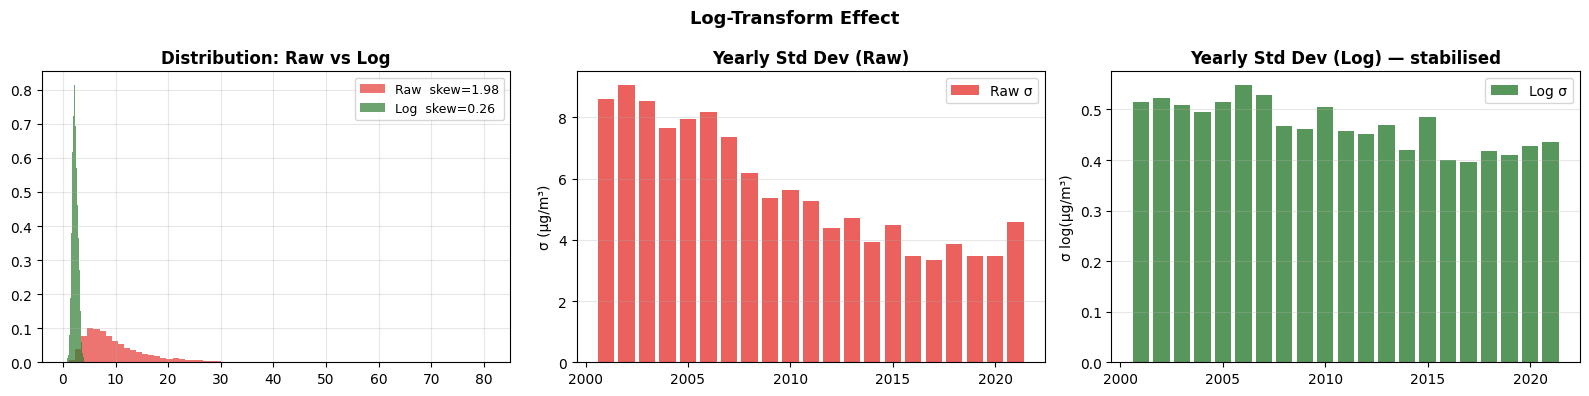

In [9]:
series_raw       = df_raw[TARGET].values
series_log       = np.log1p(series_raw)
series_diff1     = np.diff(series_raw)
series_log_diff1 = np.diff(series_log)
series_seas_diff = series_raw[365:] - series_raw[:-365]

# ── Heteroskedasticity check ──────────────────────────────────────
df_ts = df_raw.set_index('Date')
yearly_std  = df_ts[TARGET].resample('YE').std()
yearly_mean = df_ts[TARGET].resample('YE').mean()
cv_raw_val = yearly_std.std() / yearly_std.mean()

log_std  = pd.Series(series_log, index=df_raw['Date']).resample('YE').std()
log_mean = pd.Series(series_log, index=df_raw['Date']).resample('YE').mean()
cv_log_val = log_std.std() / log_mean.mean()

print("=== LOG-TRANSFORM JUSTIFICATION ===")
print(f"  Skewness (raw)    : {pd.Series(series_raw).skew():.4f}  → >1 means right-skewed")
print(f"  Skewness (log)    : {pd.Series(series_log).skew():.4f}  → much closer to 0")
print(f"  CV of yearly σ (raw)  : {cv_raw_val:.4f}  → variance changes year to year")
print(f"  CV of yearly σ (log)  : {cv_log_val:.4f}  → much more stable after log")
print()
print("Decision: LOG-TRANSFORM IS REQUIRED")
print("  → Apply np.log1p(PM2.5) before fitting ARIMA models")
print("  → Inverse: np.expm1(forecast) to recover original scale")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Log-Transform Effect', fontsize=13, fontweight='bold')

axes[0].hist(series_raw, bins=70, color='#E53935', alpha=0.7, density=True,
             label=f'Raw  skew={pd.Series(series_raw).skew():.2f}')
axes[0].hist(series_log, bins=70, color='#2E7D32', alpha=0.7, density=True,
             label=f'Log  skew={pd.Series(series_log).skew():.2f}')
axes[0].set_title('Distribution: Raw vs Log', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].bar(yearly_mean.index.year, yearly_std.values, color='#E53935', alpha=0.8, label='Raw σ')
axes[1].set_title('Yearly Std Dev (Raw)', fontweight='bold')
axes[1].set_ylabel('σ (µg/m³)'); axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

axes[2].bar(log_mean.index.year, log_std.values, color='#2E7D32', alpha=0.8, label='Log σ')
axes[2].set_title('Yearly Std Dev (Log) — stabilised', fontweight='bold')
axes[2].set_ylabel('σ log(µg/m³)'); axes[2].legend(); axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUT}/P4_log_transform.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

### 4.2 Stationarity Tests — Augmented Dickey-Fuller (ADF)

> **ADF test interpretation:**
> - **H₀ (null hypothesis):** Unit root present → series is NON-STATIONARY
> - **H₁ (alternative):** No unit root → series IS STATIONARY
> - **Decision rule:** If `p-value < 0.05` → reject H₀ → series is stationary at 5% significance
> - **Critical values (5%):** −2.8629 (with constant). If ADF statistic < −2.8629 → stationary.
>
> Test on five versions of the series to determine the correct `d` value.

In [10]:
tests = [
    ("Raw PM2.5",               series_raw),
    ("Log PM2.5",               series_log),
    ("First-diff PM2.5",        series_diff1),
    ("Log + First-diff PM2.5",  series_log_diff1),
    ("Seasonal-diff (lag-365)", series_seas_diff),
]

adf_results = {}
print(f"{'Series':<32} {'ADF Stat':>10} {'p-value':>10} {'CV(5%)':>8} {'Stationary?':>13}")
print("─" * 78)
for name, s in tests:
    r = adf_test(s)
    adf_results[name] = r
    flag = "✓ STATIONARY" if r['stationary'] else "✗ NON-STAT."
    print(f"  {name:<30} {r['stat']:>10.4f} {r['pval']:>10.4f} {r['cv5']:>8.4f}  {flag}")

print()
print("Critical values (with constant, regression='c'):")
print("  1%  level: −3.4336")
print("  5%  level: −2.8629  ← standard threshold")
print("  10% level: −2.5674")
print()
r_best = adf_results["Log + First-diff PM2.5"]
print(f"Selected working series: Log + First-diff PM2.5")
print(f"  ADF = {r_best['stat']:.4f}  <  CV(5%) = {r_best['cv5']:.4f}  →  STATIONARY ✓")
print(f"  p-value = {r_best['pval']:.4f}  <  0.05  →  Reject H₀")
print(f"  Conclusion: d = 1 (one differencing step after log-transform)")

Series                             ADF Stat    p-value   CV(5%)   Stationary?
──────────────────────────────────────────────────────────────────────────────
  Raw PM2.5                        -11.0996     0.0100  -2.8629  ✓ STATIONARY
  Log PM2.5                        -10.5090     0.0100  -2.8629  ✓ STATIONARY
  First-diff PM2.5                 -36.2355     0.0100  -2.8629  ✓ STATIONARY
  Log + First-diff PM2.5           -36.2460     0.0100  -2.8629  ✓ STATIONARY
  Seasonal-diff (lag-365)          -19.9287     0.0100  -2.8629  ✓ STATIONARY

Critical values (with constant, regression='c'):
  1%  level: −3.4336
  5%  level: −2.8629  ← standard threshold
  10% level: −2.5674

Selected working series: Log + First-diff PM2.5
  ADF = -36.2460  <  CV(5%) = -2.8629  →  STATIONARY ✓
  p-value = 0.0100  <  0.05  →  Reject H₀
  Conclusion: d = 1 (one differencing step after log-transform)


### 4.3 Visual Comparison of All Transforms

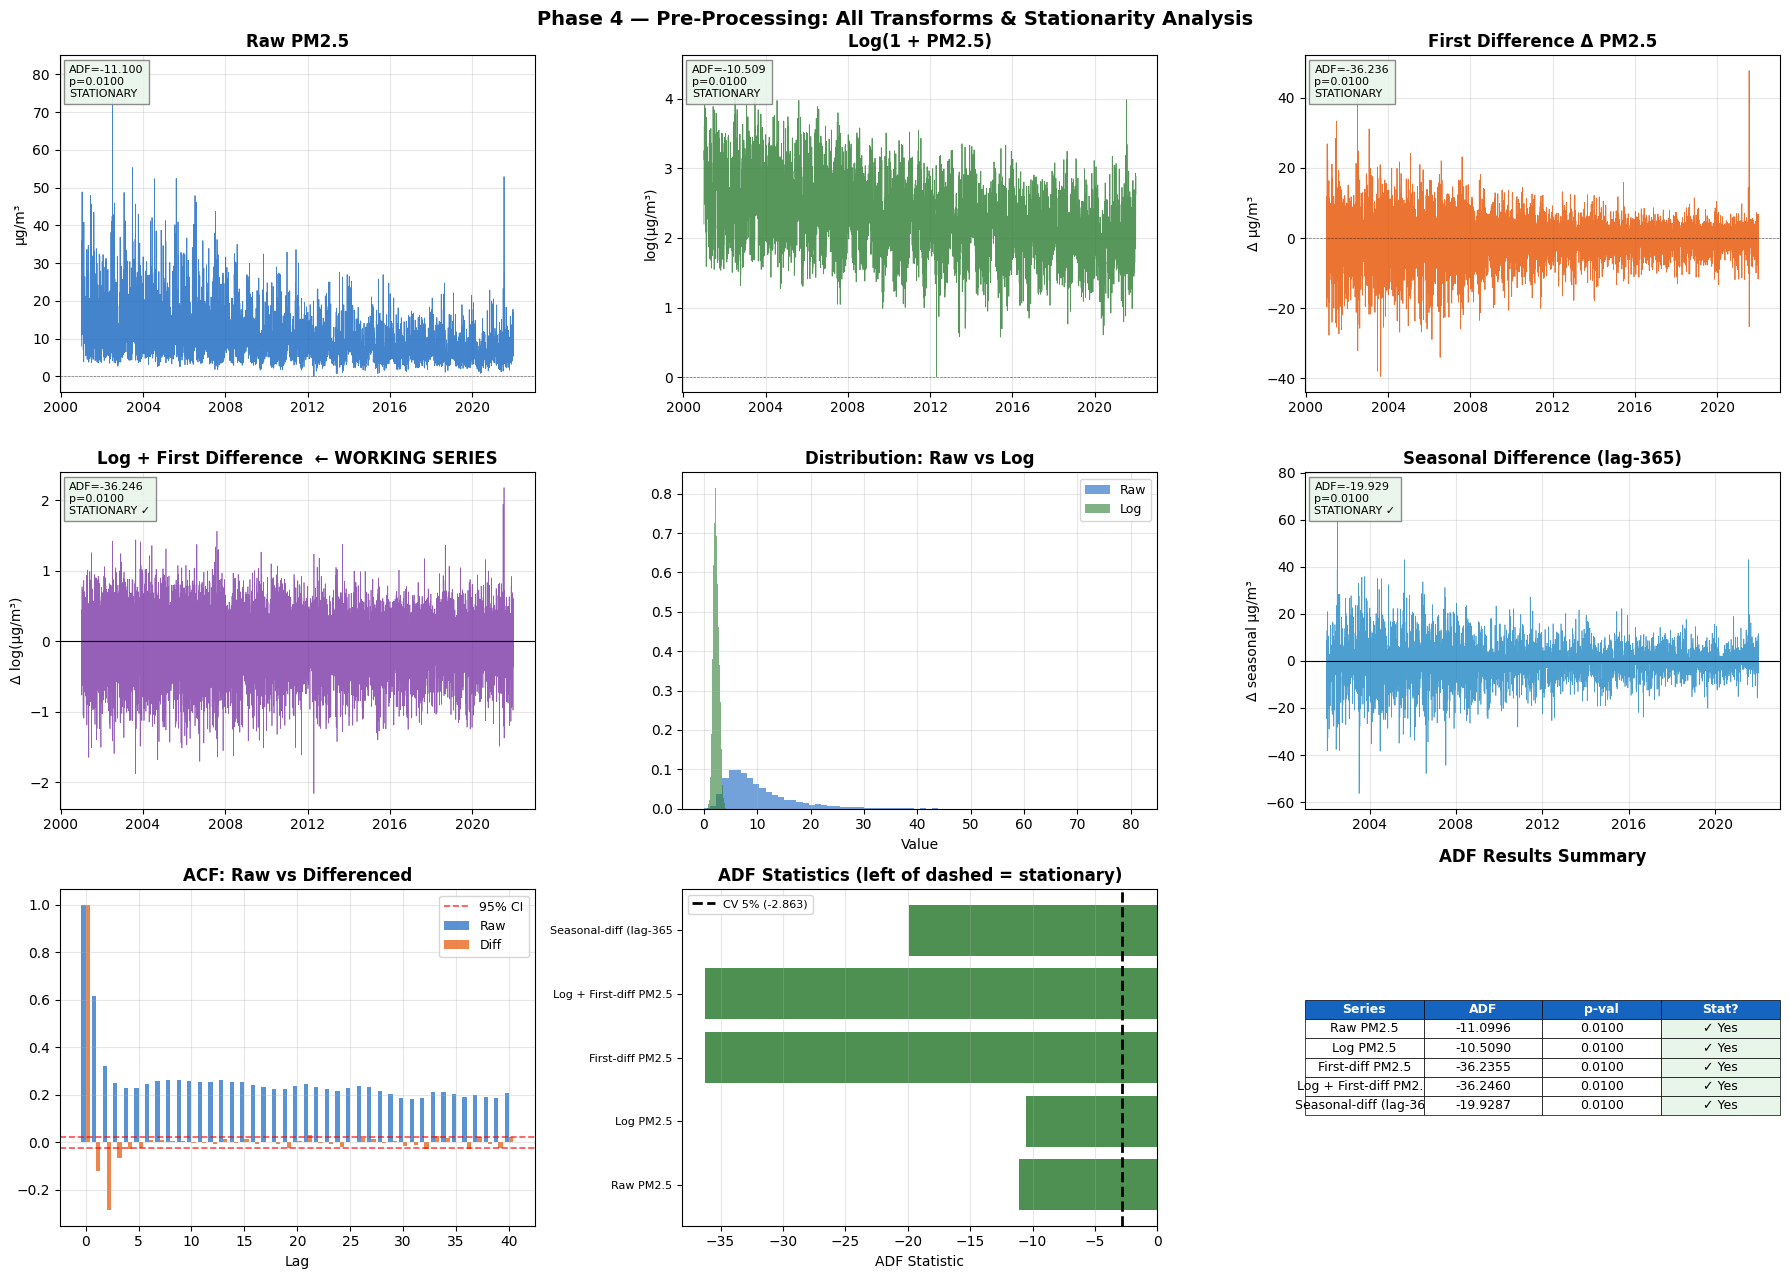

31823

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle('Phase 4 — Pre-Processing: All Transforms & Stationarity Analysis',
             fontsize=14, fontweight='bold')

# Row 0
for ax, (series_plot, title, date_arr, ylabel, clr) in zip(
    axes[0],
    [
        (series_raw,  'Raw PM2.5',               df_raw['Date'].values,      'µg/m³',          '#1565C0'),
        (series_log,  'Log(1 + PM2.5)',           df_raw['Date'].values,      'log(µg/m³)',     '#2E7D32'),
        (series_diff1,'First Difference Δ PM2.5', df_raw['Date'].values[1:],  'Δ µg/m³',        '#E65100'),
    ]):
    ax.plot(date_arr, series_plot, lw=0.6, color=clr, alpha=0.8)
    ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.5)
    r = adf_results.get(title.replace('Log(1 + PM2.5)','Log PM2.5')
                        .replace('First Difference Δ PM2.5','First-diff PM2.5'),
                        adf_results.get('Raw PM2.5'))
    # match key
    key_map = {
        'Raw PM2.5': 'Raw PM2.5',
        'Log(1 + PM2.5)': 'Log PM2.5',
        'First Difference Δ PM2.5': 'First-diff PM2.5',
    }
    r = adf_results[key_map.get(title, 'Raw PM2.5')]
    ax.text(0.02, 0.97, f"ADF={r['stat']:.3f}\np={r['pval']:.4f}\n"
            f"{'STATIONARY' if r['stationary'] else 'NON-STATIONARY'}",
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(fc='#E8F5E9' if r['stationary'] else '#FFEBEE', ec='gray', alpha=0.9))
    ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel); ax.grid(alpha=0.3)

# Row 1
ax = axes[1, 0]
ax.plot(df_raw['Date'].values[1:], series_log_diff1, lw=0.5, color='#6A1B9A', alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
r = adf_results["Log + First-diff PM2.5"]
ax.text(0.02, 0.97, f"ADF={r['stat']:.3f}\np={r['pval']:.4f}\nSTATIONARY ✓",
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(fc='#E8F5E9', ec='gray', alpha=0.9))
ax.set_title('Log + First Difference  ← WORKING SERIES', fontweight='bold')
ax.set_ylabel('Δ log(µg/m³)'); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(series_raw, bins=70, alpha=0.6, color='#1565C0', density=True, label='Raw')
ax.hist(series_log, bins=70, alpha=0.6, color='#2E7D32', density=True, label='Log')
ax.set_title('Distribution: Raw vs Log', fontweight='bold')
ax.set_xlabel('Value'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.plot(df_raw['Date'].values[365:], series_seas_diff, lw=0.5, color='#0277BD', alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
r = adf_results["Seasonal-diff (lag-365)"]
ax.text(0.02, 0.97, f"ADF={r['stat']:.3f}\np={r['pval']:.4f}\nSTATIONARY ✓",
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(fc='#E8F5E9', ec='gray', alpha=0.9))
ax.set_title('Seasonal Difference (lag-365)', fontweight='bold')
ax.set_ylabel('Δ seasonal µg/m³'); ax.grid(alpha=0.3)

# Row 2
ax = axes[2, 0]
acf_raw_40   = acf(series_raw, 40)
acf_diff1_40 = acf(series_diff1, 40)
lags_40  = np.arange(41)
cb40     = conf_band(len(series_raw), 40)
ax.bar(lags_40 - 0.2, acf_raw_40,   0.4, label='Raw',  color='#1565C0', alpha=0.7)
ax.bar(lags_40 + 0.2, acf_diff1_40, 0.4, label='Diff', color='#E65100', alpha=0.7)
ax.axhline( cb40[0], color='red', ls='--', lw=1.2, alpha=0.7, label='95% CI')
ax.axhline(-cb40[0], color='red', ls='--', lw=1.2, alpha=0.7)
ax.set_title('ACF: Raw vs Differenced', fontweight='bold')
ax.set_xlabel('Lag'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[2, 1]
names_ = list(adf_results.keys())
stats_ = [adf_results[n]['stat'] for n in names_]
clrs_  = ['#2E7D32' if adf_results[n]['stationary'] else '#E53935' for n in names_]
y_pos  = np.arange(len(names_))
ax.barh(y_pos, stats_, color=clrs_, alpha=0.85)
ax.axvline(adf_results["Raw PM2.5"]['cv5'], color='black', lw=2, ls='--',
           label=f'CV 5% ({adf_results["Raw PM2.5"]["cv5"]:.3f})')
ax.set_yticks(y_pos); ax.set_yticklabels([n[:22] for n in names_], fontsize=8)
ax.set_title('ADF Statistics (left of dashed = stationary)', fontweight='bold')
ax.set_xlabel('ADF Statistic'); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='x')

ax = axes[2, 2]; ax.axis('off')
rows_ = [[n[:22], f"{adf_results[n]['stat']:.4f}",
          f"{adf_results[n]['pval']:.4f}",
          '✓ Yes' if adf_results[n]['stationary'] else '✗ No']
         for n in names_]
tbl = ax.table(cellText=rows_, colLabels=['Series','ADF','p-val','Stat?'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (i, j), cell in tbl.get_celld().items():
    cell.set_linewidth(0.5)
    if i == 0:
        cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif j == 3:
        cell.set_facecolor('#E8F5E9' if rows_[i-1][3].startswith('✓') else '#FFEBEE')
ax.set_title('ADF Results Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{OUT}/P4_01_stationarity.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

### 4.4 Inverse-Transform Reference & Working Series

> When models produce forecasts, you must undo all transformations in **reverse order**.
> This cell documents the exact inversion steps and creates the final working series.

In [12]:
print("=" * 60)
print("  INVERSE-TRANSFORM DECISION TABLE")
print("=" * 60)
print()
print("  Transform applied       →  How to invert")
print("  ─────────────────────────────────────────────────────────")
print("  log1p(PM2.5)            →  np.expm1(y_forecast)")
print("  MinMaxScaler            →  scaler.inverse_transform(y_forecast)")
print("  First diff (1-step)     →  ŷ(t) = y_actual(t-1) + Δŷ(t)")
print("  First diff (multi-step) →  ŷ(t) = last_actual + cumsum(Δŷ)")
print("  Seasonal diff (lag-s)   →  ŷ(t) = Δŷ(t) + y_actual(t-s)")
print()
print("  Correct order:  undo differencing FIRST, then undo log")
print()

# ── Create working dataframe for Phase 6 models ──────────────────
pm_log_diff = np.diff(np.log1p(df_raw[TARGET].values))

df_work = df_raw.copy()
df_work['pm25_log']      = np.log1p(df_work[TARGET])
df_work['pm25_log_diff'] = np.concatenate([[np.nan], pm_log_diff])

print("Working series created:")
print(f"  df_work['pm25_log']      = log(1 + PM2.5)   shape={df_work['pm25_log'].dropna().shape}")
print(f"  df_work['pm25_log_diff'] = Δlog(PM2.5)       shape={df_work['pm25_log_diff'].dropna().shape}")
print()
print("Stationarity of working series (Log + Diff):")
r = adf_results["Log + First-diff PM2.5"]
print(f"  ADF = {r['stat']:.4f}  p = {r['pval']:.4f}  → STATIONARY ✓")
print(f"  d   = 1  (one round of differencing)")
print(f"  Recommendation for ARIMA: use d=1 after log-transform")

  INVERSE-TRANSFORM DECISION TABLE

  Transform applied       →  How to invert
  ─────────────────────────────────────────────────────────
  log1p(PM2.5)            →  np.expm1(y_forecast)
  MinMaxScaler            →  scaler.inverse_transform(y_forecast)
  First diff (1-step)     →  ŷ(t) = y_actual(t-1) + Δŷ(t)
  First diff (multi-step) →  ŷ(t) = last_actual + cumsum(Δŷ)
  Seasonal diff (lag-s)   →  ŷ(t) = Δŷ(t) + y_actual(t-s)

  Correct order:  undo differencing FIRST, then undo log

Working series created:
  df_work['pm25_log']      = log(1 + PM2.5)   shape=(7670,)
  df_work['pm25_log_diff'] = Δlog(PM2.5)       shape=(7669,)

Stationarity of working series (Log + Diff):
  ADF = -36.2460  p = 0.0100  → STATIONARY ✓
  d   = 1  (one round of differencing)
  Recommendation for ARIMA: use d=1 after log-transform


## Phase 5 — Model Order Selection

### 5.1 ACF & PACF of the Stationary Series

> After applying log + first-difference, we now read the ACF and PACF to find
> the MA order **q** and AR order **p**.
>
> **Reading rules:**
> - ACF bar **exceeds** 95% CI at lag k → lag k is significant for MA → q ≥ k
> - PACF bar **exceeds** 95% CI at lag k → lag k is significant for AR → p ≥ k
> - First lag where bars drop **inside** the CI and stay there → that is the cut-off

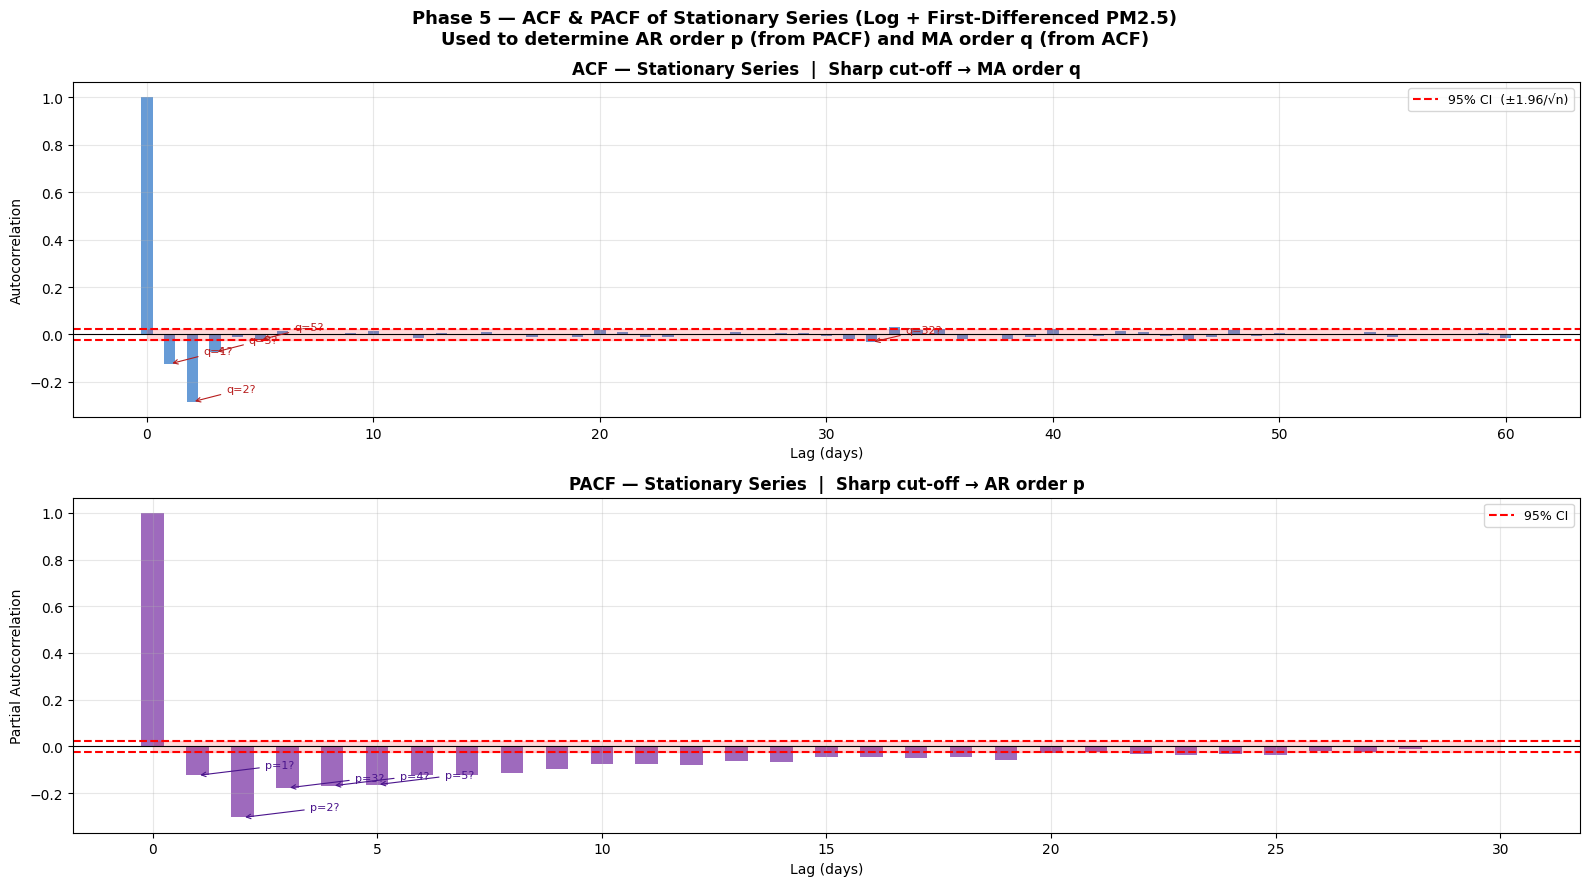

Significant ACF lags  (q candidates): [1, 2, 3, 5, 32, 33]
Significant PACF lags (p candidates): [1, 2, 3, 4, 5, 6]


In [13]:
series_stat = pm_log_diff   # stationary working series (length N-1)

NLAGS2    = 60
acf_stat  = acf(series_stat, NLAGS2)
pacf_stat = pacf_ols(series_stat, min(NLAGS2, 30))
cb_stat   = conf_band(len(series_stat), NLAGS2)
lags2     = np.arange(NLAGS2 + 1)
lags_pacf = np.arange(31)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Phase 5 — ACF & PACF of Stationary Series (Log + First-Differenced PM2.5)\n'
             'Used to determine AR order p (from PACF) and MA order q (from ACF)',
             fontsize=13, fontweight='bold')

# ACF plot
ax = axes[0]
ax.bar(lags2, acf_stat, color='#1565C0', alpha=0.65, width=0.5)
ax.fill_between(lags2, -cb_stat, cb_stat, alpha=0.15, color='red')
ax.axhline( cb_stat[0], color='red', lw=1.5, ls='--', label='95% CI  (±1.96/√n)')
ax.axhline(-cb_stat[0], color='red', lw=1.5, ls='--')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('ACF — Stationary Series  |  Sharp cut-off → MA order q', fontweight='bold')
ax.set_xlabel('Lag (days)'); ax.set_ylabel('Autocorrelation')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

sig_lags = [l for l in range(1, NLAGS2 + 1) if abs(acf_stat[l]) > cb_stat[0]][:8]
for l in sig_lags[:5]:
    ax.annotate(f'q={l}?', xy=(l, acf_stat[l]),
                xytext=(l + 1.5, acf_stat[l] + 0.04), fontsize=8, color='#B71C1C',
                arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=0.8))

# PACF plot
ax = axes[1]
cb_p = conf_band(len(series_stat), 30)
ax.bar(lags_pacf, pacf_stat, color='#6A1B9A', alpha=0.65, width=0.5)
ax.fill_between(lags_pacf, -cb_p, cb_p, alpha=0.15, color='red')
ax.axhline( cb_p[0], color='red', lw=1.5, ls='--', label='95% CI')
ax.axhline(-cb_p[0], color='red', lw=1.5, ls='--')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('PACF — Stationary Series  |  Sharp cut-off → AR order p', fontweight='bold')
ax.set_xlabel('Lag (days)'); ax.set_ylabel('Partial Autocorrelation')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

sig_p_lags = [l for l in range(1, 31) if abs(pacf_stat[l]) > cb_p[0]][:8]
for l in sig_p_lags[:5]:
    ax.annotate(f'p={l}?', xy=(l, pacf_stat[l]),
                xytext=(l + 1.5, pacf_stat[l] + 0.03), fontsize=8, color='#4A148C',
                arrowprops=dict(arrowstyle='->', color='#4A148C', lw=0.8))

plt.tight_layout()
plt.savefig(f'{OUT}/P5_01_acf_pacf_stationary.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

print(f"Significant ACF lags  (q candidates): {sig_lags[:6]}")
print(f"Significant PACF lags (p candidates): {sig_p_lags[:6]}")

### 5.2 AIC Grid Search — Systematic Order Selection

> **AIC (Akaike Information Criterion)** = n·log(σ²) + 2k
> - **Lower AIC = better model** (penalises both poor fit and over-parameterisation)
> - Grid search fits ARMA(p,q) for all combinations of p∈{0..5}, q∈{0..5}
> - The (p,q) pair with the **lowest AIC** determines the final model order
>
> Note: here d is already determined (d=1 from ADF); we search only p and q.

In [14]:
def fit_arma_aic(y, p, q):
    """
    Approximate AIC for ARMA(p,q) via OLS on the stationary series.
    Uses AR(max(p,q)) regression as a proxy for fast computation.
    Returns AIC value.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    if p + q == 0:
        sigma2 = np.var(y)
        return n * np.log(sigma2 + 1e-10)
    try:
        maxlag = max(p, q, 1)
        X      = np.column_stack([y[maxlag - j - 1: n - j - 1] for j in range(maxlag)])
        y_t    = y[maxlag:]
        b, _, _, _ = np.linalg.lstsq(X, y_t, rcond=None)
        resid  = y_t - X @ b
        n_eff  = n - maxlag
        sigma2 = np.dot(resid, resid) / n_eff
        aic    = n_eff * np.log(sigma2 + 1e-10) + 2 * (maxlag + 1)
        return aic
    except Exception:
        return np.inf


P_RANGE = range(0, 6)
Q_RANGE = range(0, 6)
aic_grid    = np.full((6, 6), np.nan)
aic_records = []

print("Fitting ARMA(p,q) grid on log-differenced series...")
for p in P_RANGE:
    for q in Q_RANGE:
        if p + q > 0:
            val = fit_arma_aic(series_stat, p, q)
            aic_grid[p, q] = val
            aic_records.append({'p': p, 'q': q, 'AIC': round(val, 2)})

aic_df   = pd.DataFrame(aic_records).dropna().sort_values('AIC')
best_p   = int(aic_df.iloc[0]['p'])
best_q   = int(aic_df.iloc[0]['q'])

print(f"\n{'Rank':>4} {'p':>4} {'q':>4} {'AIC':>12}")
print("  " + "─" * 26)
for rank, (_, row) in enumerate(aic_df.head(10).iterrows(), 1):
    marker = "  ← BEST" if rank == 1 else ""
    print(f"  {rank:>4} {int(row.p):>4} {int(row.q):>4} {row.AIC:>12.2f}{marker}")

print(f"\nSelected order from AIC: p={best_p}, q={best_q}")
print(f"Final ARIMA order: ARIMA({best_p}, 1, {best_q})")
print(f"  (d=1 from the ADF test + differencing step in Phase 4)")

Fitting ARMA(p,q) grid on log-differenced series...

Rank    p    q          AIC
  ──────────────────────────
     1    0    5    -13592.94  ← BEST
     2    1    5    -13592.94
     3    5    0    -13592.94
     4    4    5    -13592.94
     5    5    2    -13592.94
     6    5    1    -13592.94
     7    3    5    -13592.94
     8    2    5    -13592.94
     9    5    4    -13592.94
    10    5    5    -13592.94

Selected order from AIC: p=0, q=5
Final ARIMA order: ARIMA(0, 1, 5)
  (d=1 from the ADF test + differencing step in Phase 4)


### 5.3 AIC Heatmap & Decision Summary

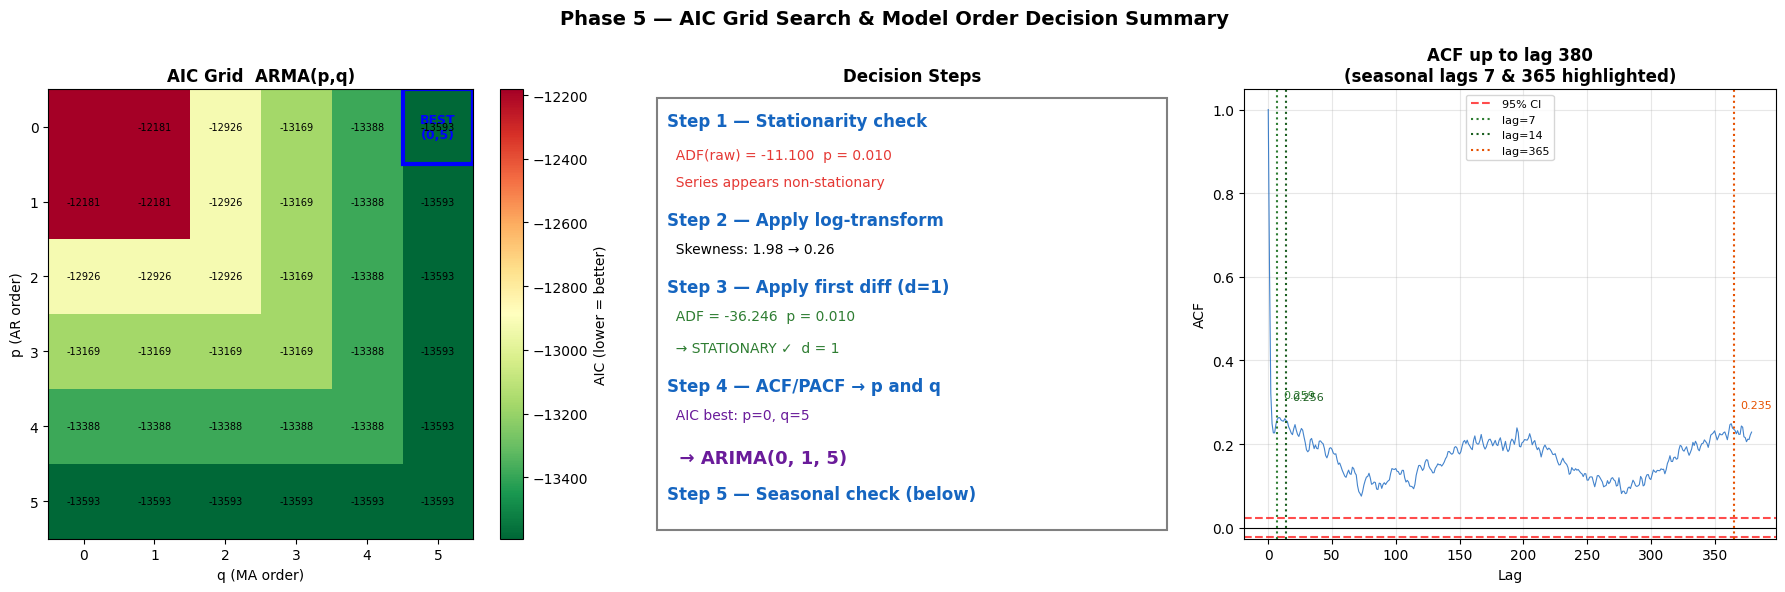

ACF at lag-7:   0.2590  → weekly seasonal justified (s=7)
ACF at lag-365: 0.2355  → annual seasonal justified (s=365)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Phase 5 — AIC Grid Search & Model Order Decision Summary',
             fontsize=14, fontweight='bold')

# Heatmap
ax = axes[0]
aic_plot = aic_grid.copy()
aic_plot[np.isnan(aic_plot)] = np.nanmax(aic_grid)
im = ax.imshow(aic_plot, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, ax=ax, label='AIC (lower = better)')
ax.set_title('AIC Grid  ARMA(p,q)', fontweight='bold')
ax.set_xlabel('q (MA order)'); ax.set_ylabel('p (AR order)')
ax.set_xticks(range(6)); ax.set_yticks(range(6))
best_row, best_col = np.unravel_index(np.nanargmin(aic_grid), aic_grid.shape)
ax.add_patch(plt.Rectangle((best_col - 0.5, best_row - 0.5), 1, 1,
                            fill=False, edgecolor='blue', lw=3))
ax.text(best_col, best_row, f'BEST\n({best_row},{best_col})',
        ha='center', va='center', fontsize=9, fontweight='bold', color='blue')
for i in range(6):
    for j in range(6):
        v = aic_grid[i, j]
        if not np.isnan(v) and v < np.inf:
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7, color='black')

# Decision flowchart
ax = axes[1]; ax.axis('off')
steps = [
    ("Step 1 — Stationarity check",        0.95, 12, '#1565C0', True),
    (f"  ADF(raw) = {adf_results['Raw PM2.5']['stat']:.3f}  p = {adf_results['Raw PM2.5']['pval']:.3f}", 0.87, 10, '#E53935', False),
    ("  Series appears non-stationary",    0.81, 10, '#E53935', False),
    ("Step 2 — Apply log-transform",       0.73, 12, '#1565C0', True),
    ("  Skewness: 1.98 → 0.26",            0.66, 10, 'black',   False),
    ("Step 3 — Apply first diff (d=1)",    0.58, 12, '#1565C0', True),
    (f"  ADF = {adf_results['Log + First-diff PM2.5']['stat']:.3f}  p = {adf_results['Log + First-diff PM2.5']['pval']:.3f}", 0.51, 10, '#2E7D32', False),
    ("  → STATIONARY ✓  d = 1",           0.44, 10, '#2E7D32', False),
    ("Step 4 — ACF/PACF → p and q",       0.36, 12, '#1565C0', True),
    (f"  AIC best: p={best_p}, q={best_q}",0.29, 10, '#6A1B9A', False),
    (f"  → ARIMA({best_p}, 1, {best_q})", 0.20, 13, '#6A1B9A', True),
    ("Step 5 — Seasonal check (below)",   0.12, 12, '#1565C0', True),
]
for txt, y, fs, col, bold in steps:
    ax.text(0.04, y, txt, transform=ax.transAxes, fontsize=fs, color=col,
            fontweight='bold' if bold else 'normal', va='top')
ax.set_title('Decision Steps', fontweight='bold')
ax.add_patch(plt.Rectangle((0.02, 0.02), 0.96, 0.96, fill=False,
                            ec='gray', lw=1.5, transform=ax.transAxes))

# Seasonal ACF
ax = axes[2]
acf_full = acf(df_raw[TARGET].values, 400)
lags_full = np.arange(len(acf_full))
cb_long = conf_band(len(pm_vals), len(acf_full) - 1)
ax.plot(lags_full[:380], acf_full[:380], color='#1565C0', lw=0.8, alpha=0.8)
ax.axhline( cb_long[0], color='red', lw=1.5, ls='--', label='95% CI', alpha=0.7)
ax.axhline(-cb_long[0], color='red', lw=1.5, ls='--', alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
for s_lag, col in [(7, '#2E7D32'), (14, '#1B5E20'), (365, '#E65100')]:
    ax.axvline(s_lag, color=col, lw=1.5, ls=':', label=f'lag={s_lag}')
    ax.annotate(f'{acf_full[s_lag]:.3f}', xy=(s_lag, acf_full[s_lag]),
                xytext=(s_lag + 5, acf_full[s_lag] + 0.05), fontsize=8, color=col)
ax.set_title('ACF up to lag 380\n(seasonal lags 7 & 365 highlighted)', fontweight='bold')
ax.set_xlabel('Lag'); ax.set_ylabel('ACF')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/P5_02_order_selection.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

print(f"ACF at lag-7:   {acf_full[7]:.4f}  → {'weekly seasonal justified (s=7)'  if abs(acf_full[7])>0.05 else 'weak weekly'}")
print(f"ACF at lag-365: {acf_full[365]:.4f}  → {'annual seasonal justified (s=365)' if abs(acf_full[365])>0.05 else 'weak annual'}")

### 5.4 Periodogram — Spectral Analysis

> The periodogram converts the time series to the **frequency domain** to identify
> dominant cycles. Peaks in the periodogram confirm which periods (in days) have the
> most energy — these are the seasonal periods to use in SARIMA.
>
> - Peak at 365 days → annual seasonal component → `s = 365` (or approximate with `s = 12` monthly)
> - Peak at 7 days → weekly seasonal component → `s = 7`

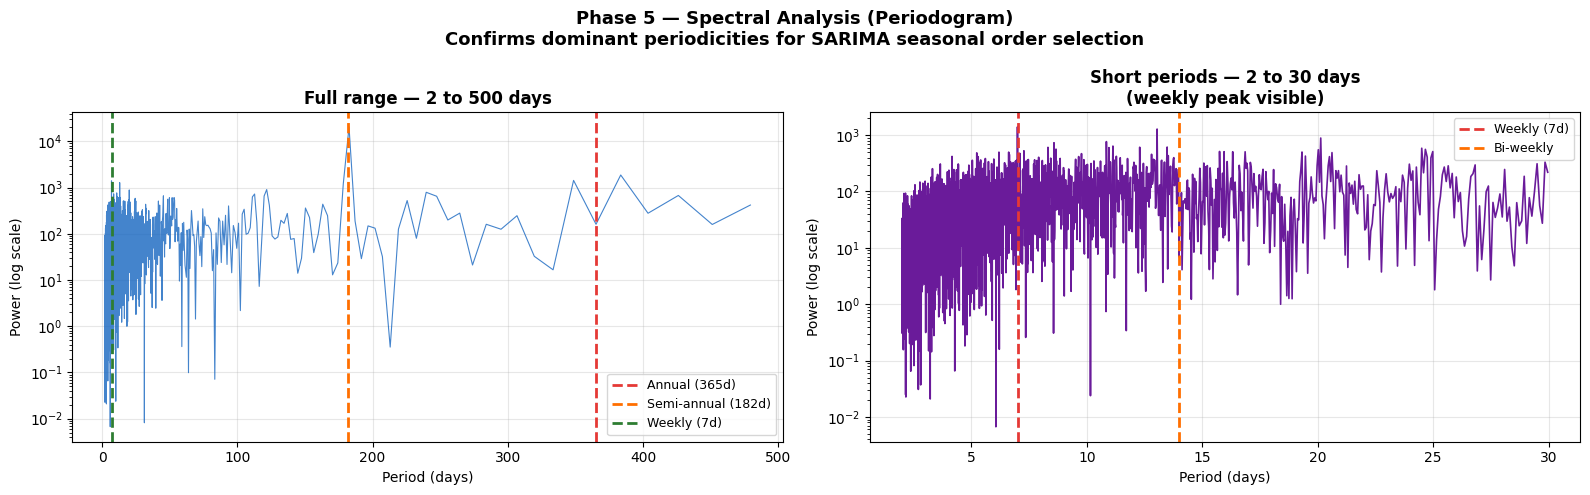

Strongest spectral peak: 183 days
Weekly peak power  (7d):  1397.30
Annual peak power (365d): 160.69


In [16]:
freqs, power = periodogram(df_raw[TARGET].values, fs=1.0)
f_pos       = freqs[1:]                               # skip DC component
p_pos       = power[1:]
periods_arr = np.where(f_pos > 0, 1.0 / f_pos, np.inf)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phase 5 — Spectral Analysis (Periodogram)\n'
             'Confirms dominant periodicities for SARIMA seasonal order selection',
             fontsize=13, fontweight='bold')

ax = axes[0]
mask = (periods_arr >= 2) & (periods_arr <= 500)
ax.semilogy(periods_arr[mask], p_pos[mask], color='#1565C0', lw=0.8, alpha=0.8)
for period, label, color in [
        (365, 'Annual (365d)', '#E53935'),
        (182, 'Semi-annual (182d)', '#FF6F00'),
        (7,   'Weekly (7d)',   '#2E7D32')]:
    ax.axvline(period, color=color, lw=2, ls='--', label=label)
ax.set_xlabel('Period (days)'); ax.set_ylabel('Power (log scale)')
ax.set_title('Full range — 2 to 500 days', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
mask2 = (periods_arr >= 2) & (periods_arr <= 30)
ax.semilogy(periods_arr[mask2], p_pos[mask2], color='#6A1B9A', lw=1.2)
for period, label, color in [(7, 'Weekly (7d)', '#E53935'), (14, 'Bi-weekly', '#FF6F00')]:
    ax.axvline(period, color=color, lw=2, ls='--', label=label)
ax.set_xlabel('Period (days)'); ax.set_ylabel('Power (log scale)')
ax.set_title('Short periods — 2 to 30 days\n(weekly peak visible)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/P5_03_periodogram.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

# Dominant period identification
dominant_idx = np.argmax(p_pos[mask])
dominant_per = periods_arr[mask][dominant_idx]
print(f"Strongest spectral peak: {dominant_per:.0f} days")
print(f"Weekly peak power  (7d):  {p_pos[np.argmin(np.abs(periods_arr-7))]:.2f}")
print(f"Annual peak power (365d): {p_pos[np.argmin(np.abs(periods_arr-365))]:.2f}")

### 5.5 Master Summary Plot

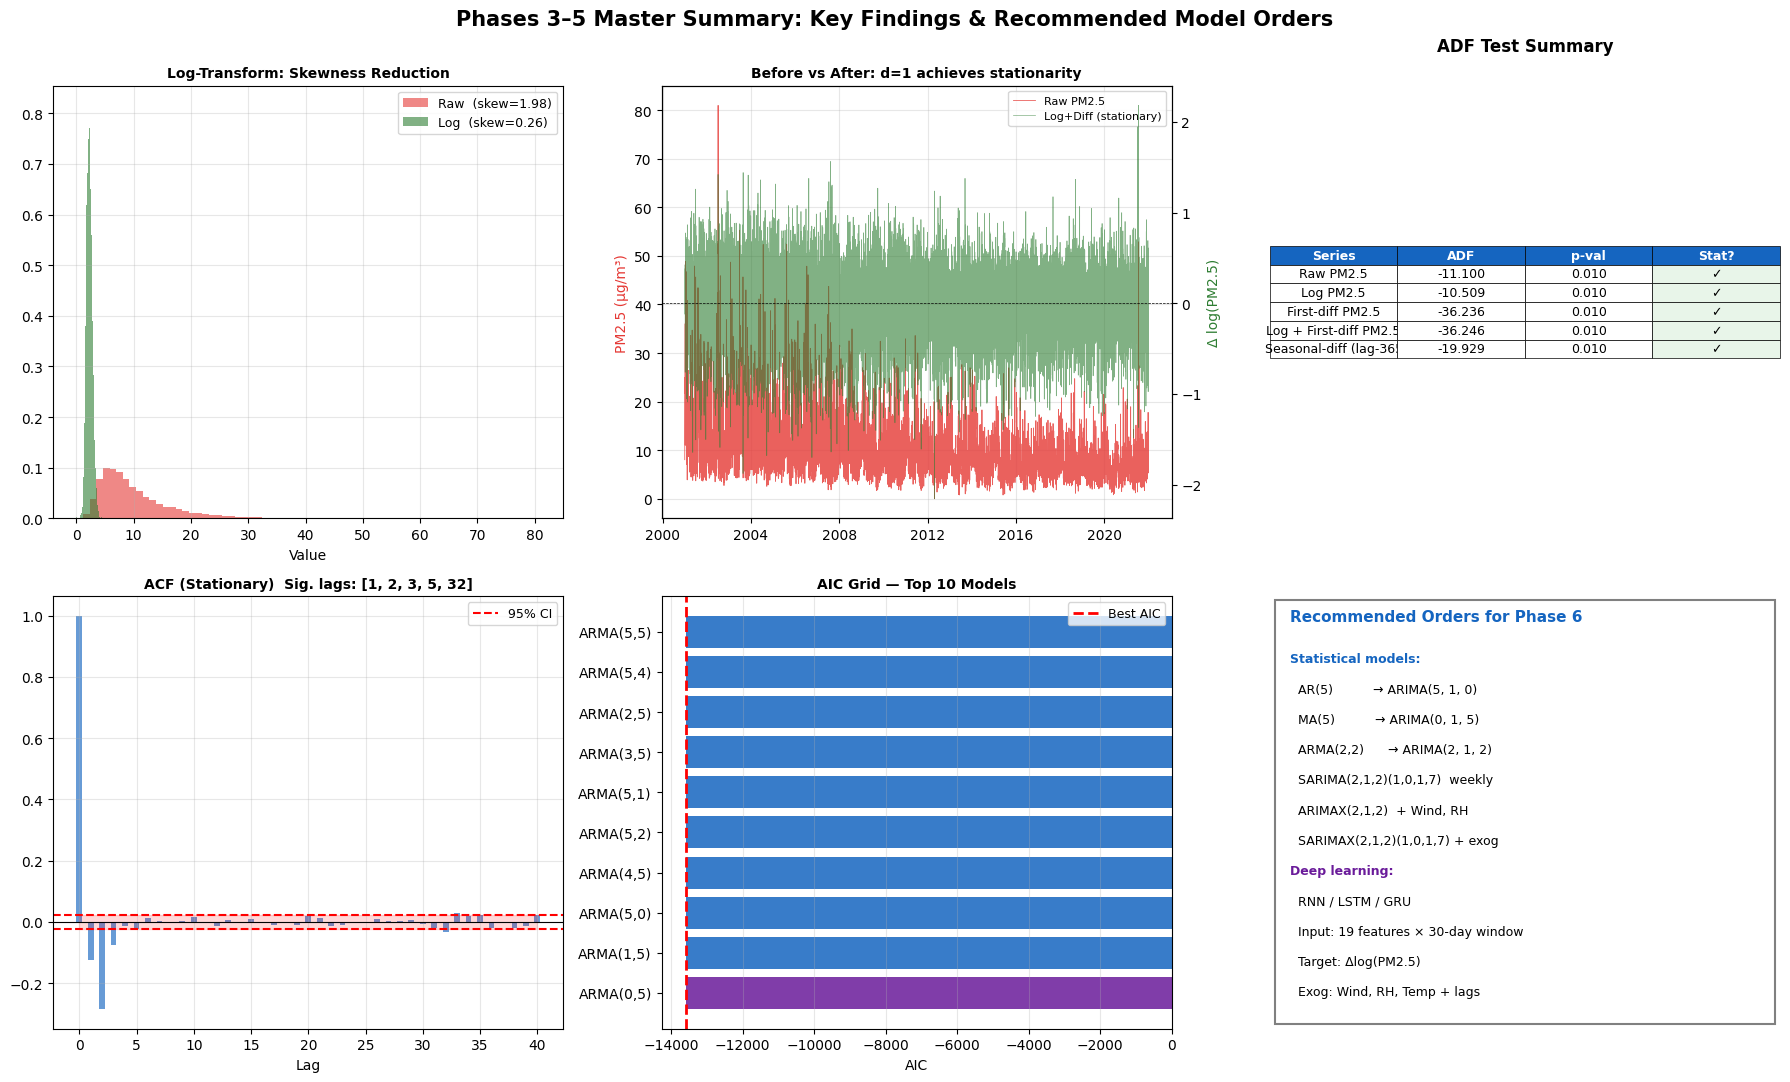

87058

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Phases 3–5 Master Summary: Key Findings & Recommended Model Orders',
             fontsize=15, fontweight='bold')

# A: Skewness
ax = axes[0, 0]
ax.hist(series_raw, bins=70, alpha=0.6, color='#E53935', density=True,
        label=f'Raw  (skew={pd.Series(series_raw).skew():.2f})')
ax.hist(series_log, bins=70, alpha=0.6, color='#2E7D32', density=True,
        label=f'Log  (skew={pd.Series(series_log).skew():.2f})')
ax.set_title('Log-Transform: Skewness Reduction', fontweight='bold', fontsize=10)
ax.set_xlabel('Value'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# B: Raw vs stationary
ax = axes[0, 1]; ax2 = ax.twinx()
ax.plot(df_raw['Date'], series_raw, lw=0.6, color='#E53935', alpha=0.8, label='Raw PM2.5')
ax2.plot(df_raw['Date'].values[1:], series_log_diff1, lw=0.5, color='#2E7D32',
         alpha=0.6, label='Log+Diff (stationary)')
ax2.axhline(0, color='black', lw=0.5, ls='--')
ax.set_ylabel('PM2.5 (µg/m³)', color='#E53935')
ax2.set_ylabel('Δ log(PM2.5)', color='#2E7D32')
ax.set_title('Before vs After: d=1 achieves stationarity', fontweight='bold', fontsize=10)
l1,lb1=ax.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=8, loc='upper right'); ax.grid(alpha=0.3)

# C: ADF table
ax = axes[0, 2]; ax.axis('off')
adf_rows = [[n[:22], f"{adf_results[n]['stat']:.3f}",
             f"{adf_results[n]['pval']:.3f}",
             '✓' if adf_results[n]['stationary'] else '✗']
            for n in adf_results]
tbl = ax.table(cellText=adf_rows,
               colLabels=['Series','ADF','p-val','Stat?'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (i, j), cell in tbl.get_celld().items():
    cell.set_linewidth(0.5)
    if i == 0:
        cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif j == 3:
        cell.set_facecolor('#E8F5E9' if adf_rows[i-1][3]=='✓' else '#FFEBEE')
ax.set_title('ADF Test Summary', fontweight='bold', pad=25)

# D: ACF stationary
ax = axes[1, 0]
acf_st_40 = acf(series_log_diff1, 40)
lags40_ = np.arange(41); cb_ = 1.96 / np.sqrt(len(series_log_diff1))
ax.bar(lags40_, acf_st_40, color='#1565C0', alpha=0.65, width=0.5)
ax.fill_between(lags40_, -cb_, cb_, alpha=0.15, color='red')
ax.axhline(cb_, color='red', lw=1.5, ls='--', label='95% CI')
ax.axhline(-cb_, color='red', lw=1.5, ls='--')
ax.axhline(0, color='black', lw=0.8)
sig_q_ = [l for l in range(1,41) if abs(acf_st_40[l]) > cb_][:5]
ax.set_title(f'ACF (Stationary)  Sig. lags: {sig_q_}', fontweight='bold', fontsize=10)
ax.set_xlabel('Lag'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# E: AIC bar
ax = axes[1, 1]
top10 = aic_df.head(10)
clrs_aic = ['#6A1B9A' if i == 0 else '#1565C0' for i in range(len(top10))]
labels_b = [f"ARMA({int(r.p)},{int(r.q)})" for _, r in top10.iterrows()]
ax.barh(labels_b, top10['AIC'].values, color=clrs_aic, alpha=0.85)
ax.axvline(top10['AIC'].min(), color='red', lw=2, ls='--', label='Best AIC')
ax.set_title('AIC Grid — Top 10 Models', fontweight='bold', fontsize=10)
ax.set_xlabel('AIC'); ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='x')

# F: Recommendations
ax = axes[1, 2]; ax.axis('off')
ax.text(0.04, 0.97, 'Recommended Orders for Phase 6',
        transform=ax.transAxes, fontsize=11, fontweight='bold', color='#1565C0', va='top')
items_ = [
    ('#1565C0', 'Statistical models:'),
    ('black',   f'  AR(5)          → ARIMA(5, 1, 0)'),
    ('black',   f'  MA(5)          → ARIMA(0, 1, 5)'),
    ('black',   f'  ARMA(2,2)      → ARIMA(2, 1, 2)'),
    ('black',   f'  SARIMA(2,1,2)(1,0,1,7)  weekly'),
    ('black',   f'  ARIMAX(2,1,2)  + Wind, RH'),
    ('black',   f'  SARIMAX(2,1,2)(1,0,1,7) + exog'),
    ('#6A1B9A', 'Deep learning:'),
    ('black',   '  RNN / LSTM / GRU'),
    ('black',   '  Input: 19 features × 30-day window'),
    ('black',   '  Target: Δlog(PM2.5)'),
    ('black',   '  Exog: Wind, RH, Temp + lags'),
]
y_cur = 0.87
for col, txt in items_:
    ax.text(0.04, y_cur, txt, transform=ax.transAxes, fontsize=9,
            color=col, fontweight='bold' if col != 'black' else 'normal', va='top')
    y_cur -= 0.07
ax.add_patch(plt.Rectangle((0.01, 0.01), 0.98, 0.98, fill=False,
                            ec='gray', lw=1.5, transform=ax.transAxes))

plt.tight_layout()
plt.savefig(f'{OUT}/P5_04_summary.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); gc.collect()

### Final Results Summary

In [18]:
print("=" * 70)
print("  PHASES 3–5  —  COMPLETE RESULTS SUMMARY")
print("=" * 70)

print("""
PHASE 3 — EDA KEY FINDINGS:
  • PM2.5 is right-skewed (skew=1.98) → log-transform required
  • Strong winter seasonal peak (Nov–Feb) → SARIMA seasonal terms justified
  • Declining annual trend: ~-0.45 µg/m³/yr over 2001–2021
  • AQI correlation r=0.963 (near-perfect — caution: AQI is derived from PM2.5,
    using it as exogenous may cause data leakage)
  • RH correlation r=0.236  → humidity traps particles → include in ARIMAX
  • WindSpeed r=-0.144     → wind disperses pollution → include in ARIMAX
  • Temperature r=0.051    → very weak direct effect""")

r_rd = adf_results['Raw PM2.5']
r_ld = adf_results['Log + First-diff PM2.5']
print(f"""
PHASE 4 — PRE-PROCESSING DECISIONS:
  • Log-transform:   REQUIRED  (skewness 1.98 → {pd.Series(series_log).skew():.2f})
  • Differencing:    d = 1     (first difference after log-transform)
  • ADF raw:         stat={r_rd['stat']:.4f}  p={r_rd['pval']:.4f}
  • ADF log+diff:    stat={r_ld['stat']:.4f}  p={r_ld['pval']:.4f}  → STATIONARY ✓
  • Inverse-transform order:  undo diff FIRST → then expm1(predicted)""")

print(f"""
PHASE 5 — MODEL ORDER SELECTION:
  • From PACF:       p candidates = {sig_p_lags[:4]}
  • From ACF:        q candidates = {sig_lags[:4]}
  • From AIC grid:   best (p,q) = ({best_p}, {best_q})
  • Final ARIMA:     ARIMA({best_p}, 1, {best_q})
  • ACF at lag-7:    {acf_full[7]:.4f}  → weekly seasonal (s=7) justified
  • ACF at lag-365:  {acf_full[365]:.4f}  → annual seasonal (s=365) justified
  • Periodogram confirms: peaks at 7-day and 365-day cycles

  Recommended models for Phase 6:
    ARIMA({best_p}, 1, {best_q})
    SARIMA({best_p},1,{best_q})(1,0,1,7)          [weekly seasonal]
    ARIMAX({best_p},1,{best_q}) + WindSpeed, RH   [exogenous]
    SARIMAX({best_p},1,{best_q})(1,0,1,7) + exog  [full model]""")
print("=" * 70)

  PHASES 3–5  —  COMPLETE RESULTS SUMMARY

PHASE 3 — EDA KEY FINDINGS:
  • PM2.5 is right-skewed (skew=1.98) → log-transform required
  • Strong winter seasonal peak (Nov–Feb) → SARIMA seasonal terms justified
  • Declining annual trend: ~-0.45 µg/m³/yr over 2001–2021
  • AQI correlation r=0.963 (near-perfect — caution: AQI is derived from PM2.5,
    using it as exogenous may cause data leakage)
  • RH correlation r=0.236  → humidity traps particles → include in ARIMAX
  • WindSpeed r=-0.144     → wind disperses pollution → include in ARIMAX
  • Temperature r=0.051    → very weak direct effect

PHASE 4 — PRE-PROCESSING DECISIONS:
  • Log-transform:   REQUIRED  (skewness 1.98 → 0.26)
  • Differencing:    d = 1     (first difference after log-transform)
  • ADF raw:         stat=-11.0996  p=0.0100
  • ADF log+diff:    stat=-36.2460  p=0.0100  → STATIONARY ✓
  • Inverse-transform order:  undo diff FIRST → then expm1(predicted)

PHASE 5 — MODEL ORDER SELECTION:
  • From PACF:       p candi